<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2025/02**


# **Entrega 4**

---

# **Análise e Previsão da Taxa de Desocupação no Brasil: Uma Abordagem Comparativa com SARIMA e XGBoost**
---

In [50]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \, \*)
Aluno1 = 'André Gustavo Monteiro dos Santos F, 10424359' #@param {type:"string"}
Aluno2 = 'Raul Santos Lages, 10424621' #@param {type:"string"}

# **Resumo**

A previsão da taxa de desocupação é fundamental para o planejamento estratégico em economias voláteis como a brasileira. Este artigo compara modelos preditivos aplicados à taxa nacional, utilizando dados da PNAD Contínua do IBGE. Avalia-se a performance relativa da estatística clássica (SARIMA) versus o aprendizado de máquina (XGBoost). Metodologicamente, o estudo abordou a estacionariedade, sazonalidade e feature engineering com defasagens temporais. A avaliação baseou-se nas métricas RMSE, MAE e MAPE. Os resultados discutem os trade-offs entre a interpretabilidade econométrica e a capacidade de generalização não-linear do algoritmo de boosting frente às oscilações recentes do mercado de trabalho.

**Palavras-chave**: Séries Temporais; Taxa de Desocupação; SARIMA; XGBoost; PNAD Contínua.


# **Introdução**

O mercado de trabalho atua como um pilar central para o desenvolvimento socioeconômico, sendo a taxa de desocupação um dos principais termômetros da estabilidade do Brasil. Historicamente influenciada por ciclos econômicos e políticos, essa variável sofreu, em anos recentes, o impacto de eventos globais críticos, como a pandemia de COVID-19. Esse cenário introduziu uma volatilidade sem precedentes e quebras estruturais que desafiam a acurácia dos modelos de previsão tradicionais. A motivação central deste projeto reside justamente na profunda relevância social e econômica de antecipar tais movimentos, uma vez que projeções assertivas são insumos indispensáveis tanto para a formulação de políticas públicas de amparo ao trabalhador quanto para decisões estratégicas de investimento no setor privado.

A crescente complexidade do cenário macroeconômico levanta questionamentos sobre a suficiência de projeções baseadas exclusivamente em modelos lineares clássicos em períodos de alta incerteza. A hipótese técnica que norteia este estudo é a de que abordagens de aprendizado de máquina, por sua capacidade de capturar padrões não-lineares e incorporar variáveis exógenas, podem oferecer um desempenho superior aos modelos econométricos tradicionais em contextos de crise. Essa investigação ganha justificativa prática pelo seu impacto direto na vida de milhões de brasileiros e alinha-se ao Objetivo de Desenvolvimento Sustentável (ODS) 8 da ONU, que visa promover o trabalho decente e o crescimento econômico sustentado.

Diante desse desafio, o objetivo geral deste trabalho é desenvolver e comparar modelos preditivos de séries temporais para projetar a taxa de desemprego no Brasil, confrontando a abordagem econométrica clássica com técnicas de aprendizado de máquina. Para viabilizar essa análise, foi estruturada uma base de dados multivariada e robusta, consolidando 20 arquivos de fontes oficiais, como o Instituto Brasileiro de Geografia e Estatística (IBGE) e o Banco Central do Brasil (BCB), e fontes de dados alternativos, especificamente o Google Trends. A base contempla a série histórica da PNAD Contínua e variáveis explicativas cruciais, como Taxa Selic, IPCA, Câmbio, IBC-Br e o volume de buscas por termos como "seguro desemprego", abrangendo o período de março de 2012 (início da série da PNAD Contínua) a agosto de 2025.

Metodologicamente, o projeto propõe-se a analisar as características intrínsecas da série temporal, identificando tendências e sazonalidades, para então implementar e avaliar comparativamente dois modelos distintos: o SARIMA, representando a econometria tradicional, e o XGBoost, representando os algoritmos de gradient boosting. O desempenho dessas abordagens será aferido por meio de métricas de erro consagradas (RMSE, MAE e MAPE), analisando-se o trade-off entre a acurácia preditiva e a interpretabilidade, com o intuito final de sintetizar recomendações que apoiem o planejamento de políticas voltadas ao mercado de trabalho brasileiro.


# **Referencial Teórico**

A previsão de variáveis macroeconômicas, como a taxa de desemprego, tem sido historicamente dominada por modelos econométricos lineares. Desde a crítica seminal de Sims (1980) às restrições arbitrárias dos modelos estruturais, a literatura evoluiu para priorizar a estrutura dinâmica dos dados. No entanto, a complexidade crescente dos ciclos econômicos e a disponibilidade de novos dados impulsionaram recentemente a adoção de técnicas de aprendizado de máquina.

**A Variável de Estudo: Taxa de Desocupação (PNAD)**

A variável dependente (yt) deste estudo é a taxa de desocupação medida pela PNAD Contínua. Trata-se de uma série temporal não-estacionária, apresentando tendência e sazonalidade trimestral. Para a modelagem correta, a variável exige transformações específicas dependendo da família do algoritmo utilizado.

**A Integração entre Econometria e Aprendizado de Máquina**

A literatura recente oferece um rico panorama de comparações e integrações entre abordagens estatísticas e algorítmicas. O trabalho seminal de Athey e Imbens (2019) fornece a justificativa teórica central para este projeto, defendendo que métodos de aprendizado de máquina não devem substituir, mas sim complementar a pesquisa econômica, especialmente para alavancar o poder preditivo em cenários de alta dimensionalidade. Adicionalmente, revisões de literatura, como a de Shobana e Umamaheswari (2021), validam a seleção de modelos deste projeto como representativa do "estado da arte", confirmando a relevância contemporânea da comparação direta entre abordagens econométricas clássicas e algoritmos de gradient boosting.

**SARIMA**

O modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average) é a extensão do clássico ARIMA proposta por Box e Jenkins (1970) para séries com periodicidade definida. O modelo decompõe a variável em componentes autorregressivos (AR), de integração (I) e de médias móveis (MA), tratando a série de forma univariada. Sua principal força reside na interpretabilidade e na capacidade de capturar a sazonalidade estocástica inerente a dados trimestrais como os da PNAD.

**XGBoost**

O XGBoost (eXtreme Gradient Boosting), proposto por Chen e Guestrin (2016), representa a evolução dos algoritmos de ensemble baseados em árvores de decisão. Diferente do SARIMA, o XGBoost exige a transformação do problema de série temporal em um problema de aprendizado supervisionado através da criação de janelas de defasagem (lags). Sua vantagem teórica reside na capacidade de modelar não-linearidades complexas e interações entre variáveis sem assumir premissas rígidas sobre a distribuição dos dados. Nesse contexto, Medeiros et al. (2021) demonstram que métodos baseados em árvores podem superar modelos lineares tradicionais na previsão de variáveis macroeconômicas brasileiras, capturando com maior eficácia os choques e a volatilidade inerente a esses indicadores.

**Estado da Arte e Estudos Empíricos**

Estudos empíricos recentes revelam um trade-off claro entre modelos estocásticos e algoritmos de aprendizado de máquina. Yamacli e Yamacli (2023), ao analisarem a taxa de desemprego na Turquia (2008-2022), concluíram que, embora o modelo ARIMA se mostre robusto para períodos de estabilidade econômica, ele perde precisão durante choques estruturais, momento em que abordagens de aprendizado de máquina tendem a apresentar erros menores devido à sua flexibilidade.

Nessa linha, Krishnamurthy (2023) investigou o mercado de trabalho irlandês e destacou o desempenho superior do XGBoost em comparação a métodos tradicionais. O autor atribui esse resultado aos mecanismos intrínsecos de regularização do algoritmo, fundamentais para evitar overfitting em dados ruidosos de desemprego. Corroborando a eficácia de métodos regularizados, Mubasher et al. (2024) validaram o uso de regressões com penalização (como Lasso e Ridge, princípios matemáticos presentes no XGBoost) como ferramentas eficazes para modelar o desemprego no Paquistão.

Por fim, a literatura destaca que a performance dos modelos não depende apenas do algoritmo, mas da qualidade das variáveis de entrada (feature selection). Especificamente para o Brasil, Lasso e Snijders (2016) demonstraram que modelos de previsão de desemprego podem ser significativamente aprimorados ao incorporar dados de comportamento de busca online (Google Trends), superando benchmarks baseados puramente em sazonalidade histórica. Adu et al. (2023) confirmam esse achado para a economia de Gana, onde dados exógenos melhoraram a acurácia de modelos ARIMA, sugerindo que a engenharia de atributos é tão crítica quanto a escolha do modelo.

# **Diagrama de Solução**

A Figura 1 apresenta o fluxo completo do projeto, desde a coleta dos dados até a análise dos resultados. O diagrama reflete o pipeline implementado, abrangendo o período de análise de março de 2012 a agosto de 2025.

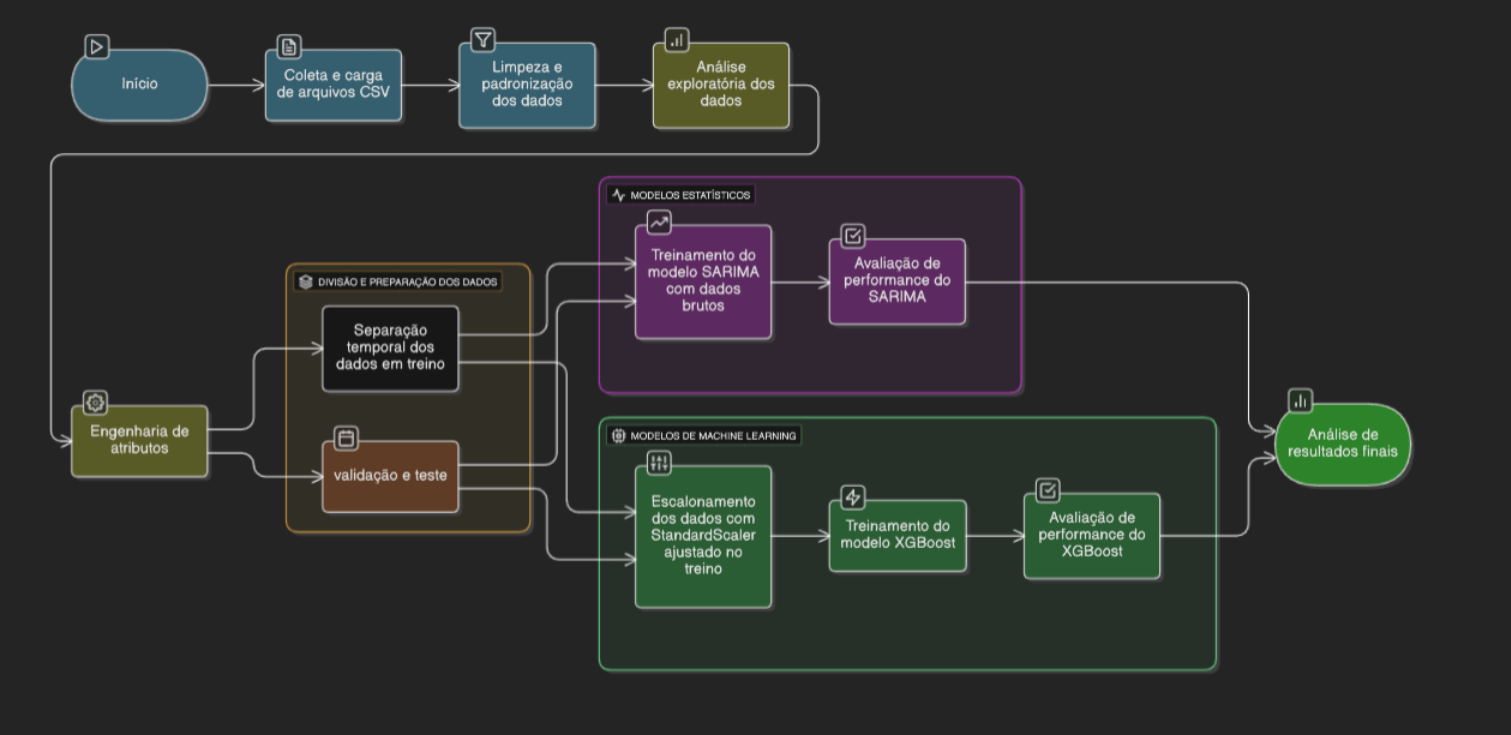

O processo inicia-se com a coleta e consolidação dos arquivos .csv, onde as bases de dados são unificadas. Na sequência, ocorre a limpeza e a padronização dos dados, garantindo a consistência temporal e o tratamento de valores ausentes.

A etapa seguinte consiste na Análise Exploratória, onde são observadas as tendências, sazonalidades e correlações. Com base nisso, aplica-se a Engenharia de Atributos, criando novas variáveis, defasagens e transformações que permitem aos modelos capturar os padrões das séries temporais.

O diagrama ilustra a divisão dos dados em treino e teste, respeitando a ordem cronológica, e a subsequente bifurcação em duas trilhas de modelagem, sendo que em uma delas, o modelo SARIMA é treinado com os dados brutos e avaliado, e na outra, os dados passam pelo escalonamento (StandardScaler) antes do treinamento e avaliação do modelo XGBoost.

Por fim, os resultados convergem na etapa de análise comparativa, utilizando as métricas RMSE, MAE e MAPE para determinar o desempenho final de cada abordagem.

# **EDA e Pré-processamento dos Dados**

### **Carga e Preparação dos Dados**

O primeiro passo consistiu na consolidação de uma base de dados multivariada. Foram lidos e processados 20 arquivos `.csv` distintos, originários de fontes como o Banco Central do Brasil (BCB), Google Trends e dados da PNAD Contínua (IBGE).

A preparação exigiu diversas etapas de limpeza e transformação:
* **Consolidação:** Os arquivos foram lidos em *loops*, tratando diferentes formatos de data (ex: 'mar/12' e '03/2012') e tipos de arquivos.
* **Padronização de Colunas:** As colunas com nomes extensos foram renomeadas para identificadores padronizados (ex: `'tx_desemprego_pnad'`).
* **Limpeza de Tipos:** Foi aplicada uma correção crítica em colunas numéricas que continham vírgulas como separadores decimais (como `endividamento_familias`), convertendo-as para *float*.

O DataFrame final consolidado (`df_final`) resultou em 162 observações (meses) cobrindo o período de março de 2012 a agosto de 2025.

### **Análise Exploratória de Dados (EDA)**

A análise exploratória focou na variável alvo, `tx_desemprego_pnad`, para entender seus padrões temporais.

* **Análise Visual:** Conforme apresentado na Figura 1, a série temporal completa revela visualmente os períodos de estresse econômico, com picos claros em 2016-2017 e durante a pandemia em 2020-2021.

![Figura 1: Série Temporal da Taxa de Desemprego](figura1_serie_temporal.png)

* **Decomposição:** Para investigar os componentes da série, foi utilizada a decomposição multiplicativa (Figura 2), que revelou uma clara tendência de alta de 2014 até 2021, seguida por reversão, além de um padrão sazonal consistente com picos no início de cada ano.

![Figura 2: Decomposição da Série Temporal](figura2_decomposicao.png)

* **Correlação e Variáveis Exógenas:** Para entender a relação entre as variáveis, foi gerado um mapa de calor (Figura 6). A variável alvo mostrou correlações negativas fortes com `ibc_br_dessazonalizado` e `tx_selic_anualizada`.

![Figura 6: Matriz de Correlação](figura6_heatmap_correlacao.png)

Como ilustrado na Figura 7, observa-se a relação econômica clássica: quando a atividade econômica sobe, o desemprego tende a cair.

![Figura 7: Desemprego vs Indicadores Macroeconômicos](figura7_macroeconomia.png)

* **Análise de Sentimento Digital (Google Trends):** A Figura 8 destaca o comportamento das variáveis de intenção de busca. Nota-se que termos como "seguro desemprego" e "benefício social" apresentaram um pico abrupto e expressivo no início da pandemia (primeiro semestre de 2020), capturando a reação imediata da população ao choque econômico antes mesmo dos indicadores oficiais, validando seu uso como variáveis preditoras (*proxies*).

![Figura 8: Desemprego vs Google Trends](figura8_google_trends.png)

### **Pré-processamento para Modelagem (Estacionariedade)**

Modelos de séries temporais como o SARIMA exigem que a série seja estacionária (média, variância e autocorrelação constantes ao longo do tempo).

* **Testes de Estacionariedade (Série Original):** Foram aplicados os testes Dickey-Fuller Aumentado (ADF) e KPSS. No ADF, o p-valor foi de 0.54 (muito acima de 0.05), falhando em rejeitar a hipótese nula de não estacionariedade. Já o KPSS indicou p-valor de 0.066. Devido à contradição dos testes e à forte tendência visual observada na Figura 1, consideramos a série original como não estacionária.

* **Transformação (Diferenciação):** Para tornar a série estacionária, aplicamos duas diferenciações. A Diferenciação Regular ($d=1$) foi aplicada para remover a tendência (visualizada na Figura 3), porém o teste ADF (p-valor 0.09) ainda falhou em confirmar a estacionariedade total devido à persistência sazonal.

![Figura 3: Série com 1ª Diferenciação](figura3_diferenciacao_regular.png)

Em seguida, a Diferenciação Sazonal ($D=1$) foi aplicada sobre a série já diferenciada para remover o padrão de 12 meses.

* **Conclusão da Estacionariedade:** Após ambas as diferenciações ($d=1$ e $D=1$), a série resultante (apresentada na Figura 4) foi aprovada em ambos os testes (ADF p-valor 0.01; KPSS p-valor 0.10), confirmando a estacionariedade. Isso justifica o uso dos parâmetros $d=1$ e $D=1$ no modelo SARIMA.

![Figura 4: Série Estacionária Final](figura4_estacionaria_final.png)

* **Análise ACF/PACF:** Com a série estacionária final, os gráficos de Autocorrelação (ACF) e Autocorrelação Parcial (PACF) foram plotados na Figura 5. A análise visual dos *lags* significativos sugere os parâmetros (1,1,1) para a ordem não sazonal e (1,1,1,12) para a ordem sazonal do modelo SARIMA.

![Figura 5: Análise de Autocorrelação](figura5_autocorrelacao.png)

In [51]:
# ==============================================================================
# 0. Configurações Iniciais e Imports
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor, plot_importance
import warnings
import glob
import os

# Configurações de visualização
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Configuração do Pandas para exibir floats
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# ==============================================================================
# 0.1. Carga e Consolidação dos Dados (ETL)
# ==============================================================================

# 1. Mapeamento de meses
mes_map = {
    'jan': '01', 'fev': '02', 'mar': '03', 'abr': '04', 'mai': '05', 'jun': '06',
    'jul': '07', 'ago': '08', 'set': '09', 'out': '10', 'nov': '11', 'dez': '12'
}

# 2. Caminho dos arquivos

# folder_path = os.path.join("data", "New")

## Obs: a ideia é deixar os arquivos csv numa pasta. Caso o exemplo acima não rodar, é só baixar os arquivos no caminho e rodar localmente tipo:
folder_path = r"C:\Users\Raul\Downloads\ProjetoAplicado\00. Projeto Aplicado 4\00. Base de Dados\New"
file_pattern = os.path.join(folder_path, "*.csv")
csv_files = glob.glob(file_pattern)

# 3. Listas para armazenar DataFrames
taxa_df = None
other_main_dfs = []
timeline_dfs = []

print(f"Iniciando consolidação de {len(csv_files)} arquivos...")

for file_path in csv_files:
    file_name = os.path.basename(file_path)
    try:
        # --- CASO 1: Google Trends ---
        if file_name.startswith('multiTimeline'):
            df = pd.read_csv(file_path, encoding='utf-8', header=1)
            df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
            df = df.set_index('Month')
            df.index.name = 'Date'
            timeline_dfs.append(df)

        # --- CASO 2: TaxaDesemprego.csv ---
        elif file_name == 'TaxaDesemprego.csv':
            df = pd.read_csv(file_path, encoding='latin-1', sep=';')
            df = df.dropna(axis=1, how='all') 
            date_col_name = df.columns[0]
            # Tratamento de data customizado
            df[date_col_name] = df[date_col_name].str.strip().str.lower().str.split('/').apply(
                lambda x: f"20{x[1]}-{mes_map[x[0]]}"
            )
            df[date_col_name] = pd.to_datetime(df[date_col_name], format='%Y-%m')
            df = df.set_index(date_col_name)
            df.index.name = 'Date'
            taxa_df = df

        # --- CASO 3: Outros arquivos (BCB, etc) ---
        else: 
            try:
                df = pd.read_csv(file_path, encoding='latin-1', sep=';', skipfooter=1, engine='python')
            except UnicodeDecodeError:
                df = pd.read_csv(file_path, encoding='utf-8', sep=';', skipfooter=1, engine='python')
            
            df = df.dropna(axis=1, how='all')
            if df.empty: continue 

            date_col_name = df.columns[0]
            primeira_data_str = df[date_col_name].iloc[0].strip().lower()
            primeira_parte = primeira_data_str.split('/')[0]

            if primeira_parte in mes_map:
                df[date_col_name] = df[date_col_name].str.strip().str.lower().str.split('/').apply(
                    lambda x: f"20{x[1]}-{mes_map[x[0]]}"
                )
                df[date_col_name] = pd.to_datetime(df[date_col_name], format='%Y-%m')
            else:
                df[date_col_name] = pd.to_datetime(df[date_col_name], format='%m/%Y')

            df = df.set_index(date_col_name)
            df.index.name = 'Date'
            other_main_dfs.append(df)

    except Exception as e:
        print(f"Erro no arquivo {file_name}: {e}")

# Consolidação
try:
    df_others = pd.concat(other_main_dfs, axis=1) if other_main_dfs else pd.DataFrame()
    df_timeline = pd.concat(timeline_dfs, axis=1) if timeline_dfs else pd.DataFrame()
    if taxa_df is None: taxa_df = pd.DataFrame()

    df_final = pd.concat([taxa_df, df_others, df_timeline], axis=1)
    
    # Renomeação
    column_map = {
        'Taxa de desemprego (desocupação)': 'tx_desemprego_pnad',
        '3695 - Taxa de câmbio - Livre - Dólar americano (compra) - Fim de período - mensal': 'cambio_compra_fim',
        '3696 - Taxa de câmbio - Livre - Dólar americano (venda) - Fim de período - mensal': 'cambio_venda_fim',
        '3697 - Taxa de câmbio - Livre - Dólar americano (compra) - Média de período - mensal': 'cambio_compra_media',
        '3698 - Taxa de câmbio - Livre - Dólar americano (venda) - Média de período - mensal': 'cambio_venda_media',
        '433 - Índice nacional de preços ao consumidor-amplo (IPCA)': 'ipca',
        '4189 - Taxa de juros - Selic acumulada no mês anualizada base 252': 'tx_selic_anualizada',
        '4390 - Taxa de juros - Selic acumulada no mês': 'tx_selic_mensal',
        '29037 - Endividamento das famílias com o Sistema Financeiro Nacional em relação à renda acumulada dos últimos doze meses (RNDBF) - %': 'endividamento_familias',
        '20714 - Taxa média de juros das operações de crédito - Total - % a.a.': 'tx_media_juros_credito_total',
        '20715 - Taxa média de juros das operações de crédito - Pessoas jurídicas - Total - % a.a.': 'tx_media_juros_credito_pj',
        '20716 - Taxa média de juros das operações de crédito - Pessoas físicas - Total - % a.a.': 'tx_media_juros_credito_pf',
        '4466 - Índice nacional de preços ao consumidor-Amplo (IPCA) - Núcleo médias aparadas com suavização - Var. % mensal': 'ipca_nucleo',
        '24363 - Índice de Atividade Econômica do Banco Central - IBC-Br - Índice': 'ibc_br',
        '24364 - Índice de Atividade Econômica do Banco Central (IBC-Br) - com ajuste sazonal - Índice': 'ibc_br_dessazonalizado',
        '29039 - Índice de Commodities - Brasil - Energia (em US Dólares) - Índice': 'ic_energia',
        '29040 - Índice de Commodities - Brasil - Metal (em US Dólares) - Índice': 'ic_metal',
        '29041 - Índice de Commodities - Brasil - Agropecuária (em US Dólares) - Índice': 'ic_agro',
        '29042 - Índice de Commodities - Brasil (em US Dólares) - Índice': 'ic_br',
        '29601 - Índice de Atividade Econômica do Banco Central (IBC-Br) Agropecuária - Índice': 'ibc_br_agro',
        'Seguro desemprego: (Brazil)': 'google_seguro_desemprego',
        'Desemprego + benefício social: (Brazil)': 'google_desempreg_beneficio_social',
        'Vagas de emprego: (Brazil)': 'google_vagas_emprego',
        'Décimo terceiro salário: (Brazil)': 'google_decimo_terceiro_salario',
        'Décimo terceiro: (Brazil)': 'google_decimo_terceiro',
        'Empregos: (Brazil)': 'google_empregos',
        'Vagas: (Brazil)': 'google_vagas',
        'FGTS: (Brazil)': 'google_fgts',
        'Saque FGTS: (Brazil)': 'google_saque_fgts',
        'INSS: (Brazil)': 'google_inss',
        'Aposentadoria: (Brazil)': 'google_aposentadoria'
    }
    df_final.rename(columns=column_map, inplace=True)

    # Limpeza de Tipos (Vírgula para Ponto)
    cols_to_clean = [
        'endividamento_familias', 'tx_media_juros_credito_total', 'tx_media_juros_credito_pj',
        'tx_media_juros_credito_pf', 'ipca_nucleo', 'ibc_br', 'ibc_br_dessazonalizado',
        'ic_energia', 'ic_metal', 'ic_agro', 'ic_br', 'ibc_br_agro'
    ]
    cols_existentes = [c for c in cols_to_clean if c in df_final.columns]
    
    for col in cols_existentes:
        df_final[col] = df_final[col].astype(str).str.replace(',', '.', regex=False)
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

    print("\nDataFrame Consolidado com Sucesso!")
    print(df_final.info())
    print(df_final.head())

except Exception as e:
    print(f"Erro Fatal na Consolidação: {e}")

Iniciando consolidação de 20 arquivos...

DataFrame Consolidado com Sucesso!
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 162 entries, 2012-03-01 to 2025-08-01
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   tx_desemprego_pnad                 162 non-null    float64
 1   cambio_compra_fim                  162 non-null    float64
 2   cambio_venda_fim                   162 non-null    float64
 3   cambio_compra_media                162 non-null    float64
 4   cambio_venda_media                 162 non-null    float64
 5   ipca                               162 non-null    float64
 6   tx_selic_anualizada                162 non-null    float64
 7   tx_selic_mensal                    162 non-null    float64
 8   endividamento_familias             162 non-null    float64
 9   tx_media_juros_credito_total       162 non-null    float64
 10  tx_media_juros_credito_pj 

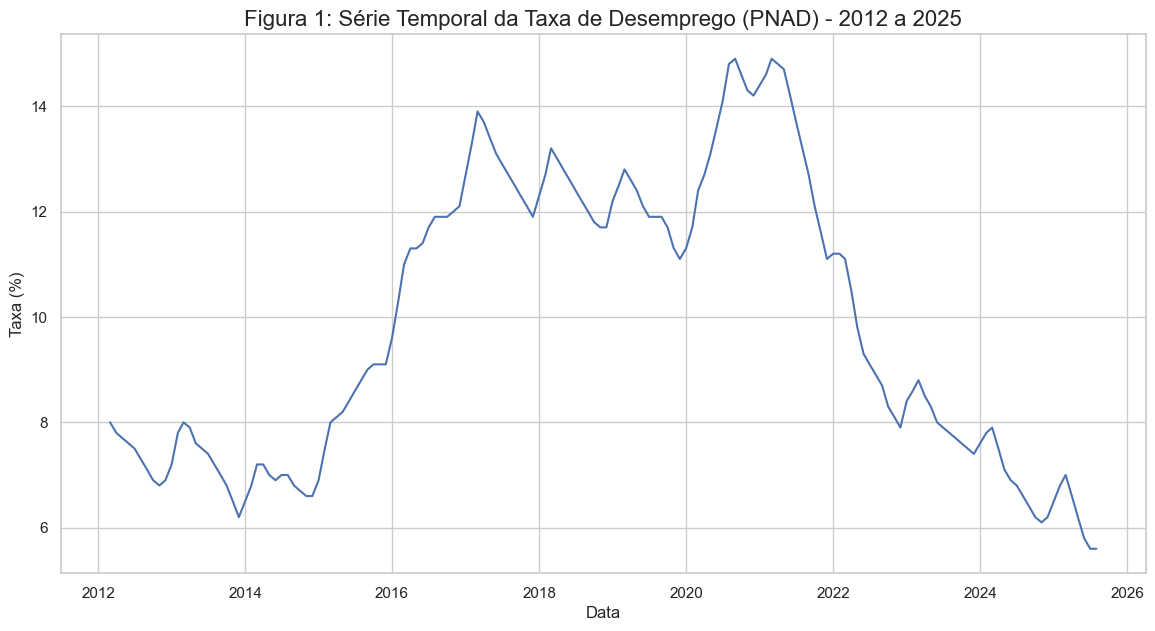

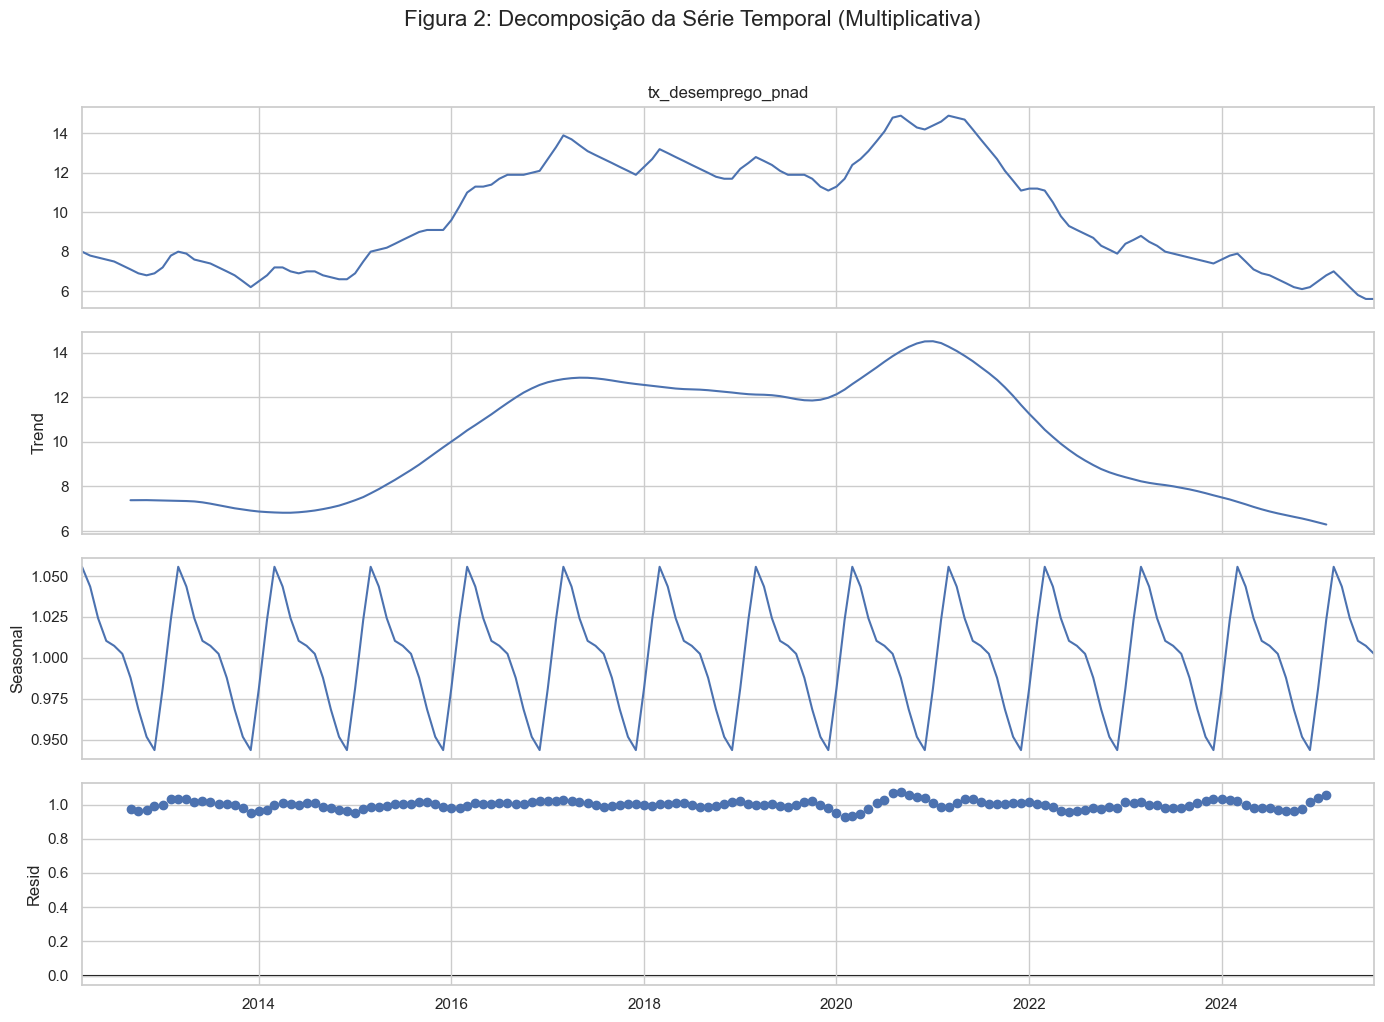


>>> Testando Estacionariedade para: Original <<<
[ADF] Estatística: -1.4804 | p-valor: 0.5432
      Resultado ADF: Falha ao rejeitar H0 -> Série NÃO é ESTACIONÁRIA.
[KPSS] Estatística: 0.4259 | p-valor: 0.0660
      Resultado KPSS: Falha ao rejeitar H0 -> Série tende a ser ESTACIONÁRIA.
------------------------------------------------------------


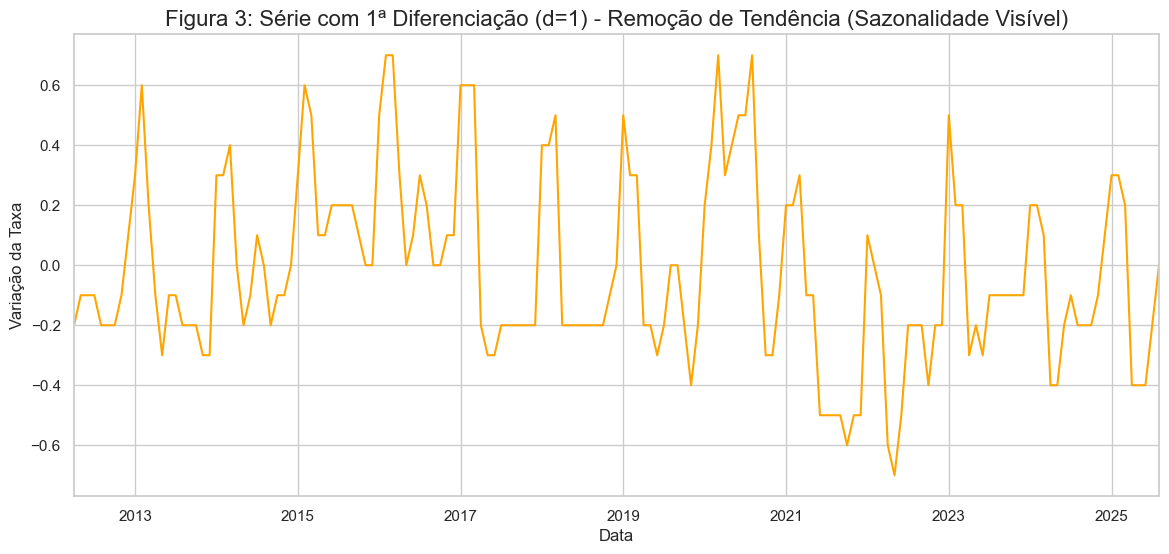


>>> Testando Estacionariedade para: Intermediária (Apenas d=1) <<<
[ADF] Estatística: -2.6050 | p-valor: 0.0920
      Resultado ADF: Falha ao rejeitar H0 -> Série NÃO é ESTACIONÁRIA.
[KPSS] Estatística: 0.4424 | p-valor: 0.0589
      Resultado KPSS: Falha ao rejeitar H0 -> Série tende a ser ESTACIONÁRIA.
------------------------------------------------------------


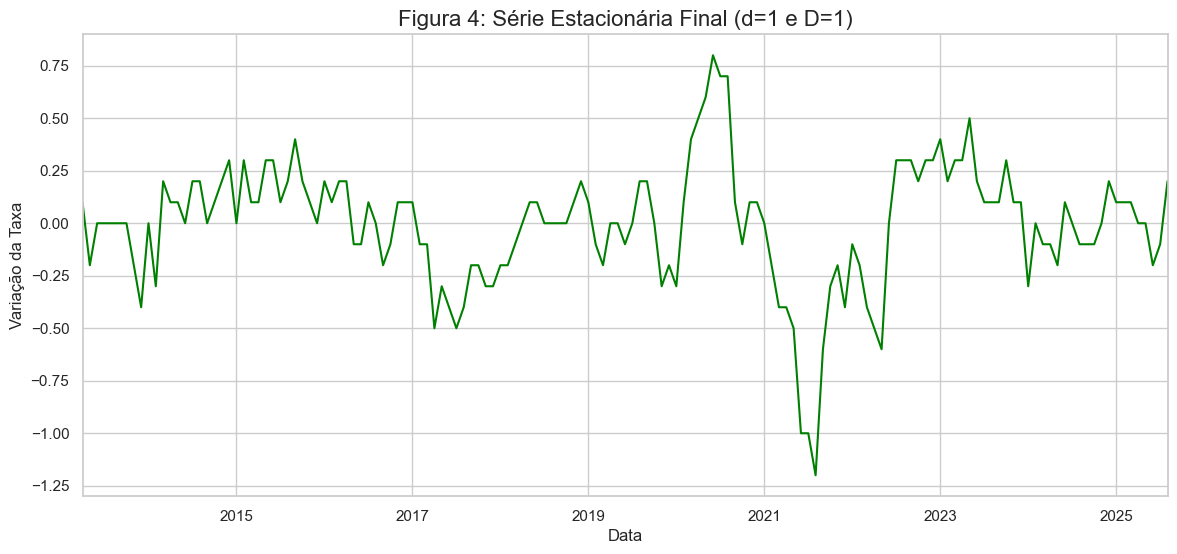


>>> Testando Estacionariedade para: Final (d=1 e D=1) <<<
[ADF] Estatística: -3.4282 | p-valor: 0.0100
      Resultado ADF: Rejeita H0 -> Série tende a ser ESTACIONÁRIA.
[KPSS] Estatística: 0.0593 | p-valor: 0.1000
      Resultado KPSS: Falha ao rejeitar H0 -> Série tende a ser ESTACIONÁRIA.
------------------------------------------------------------


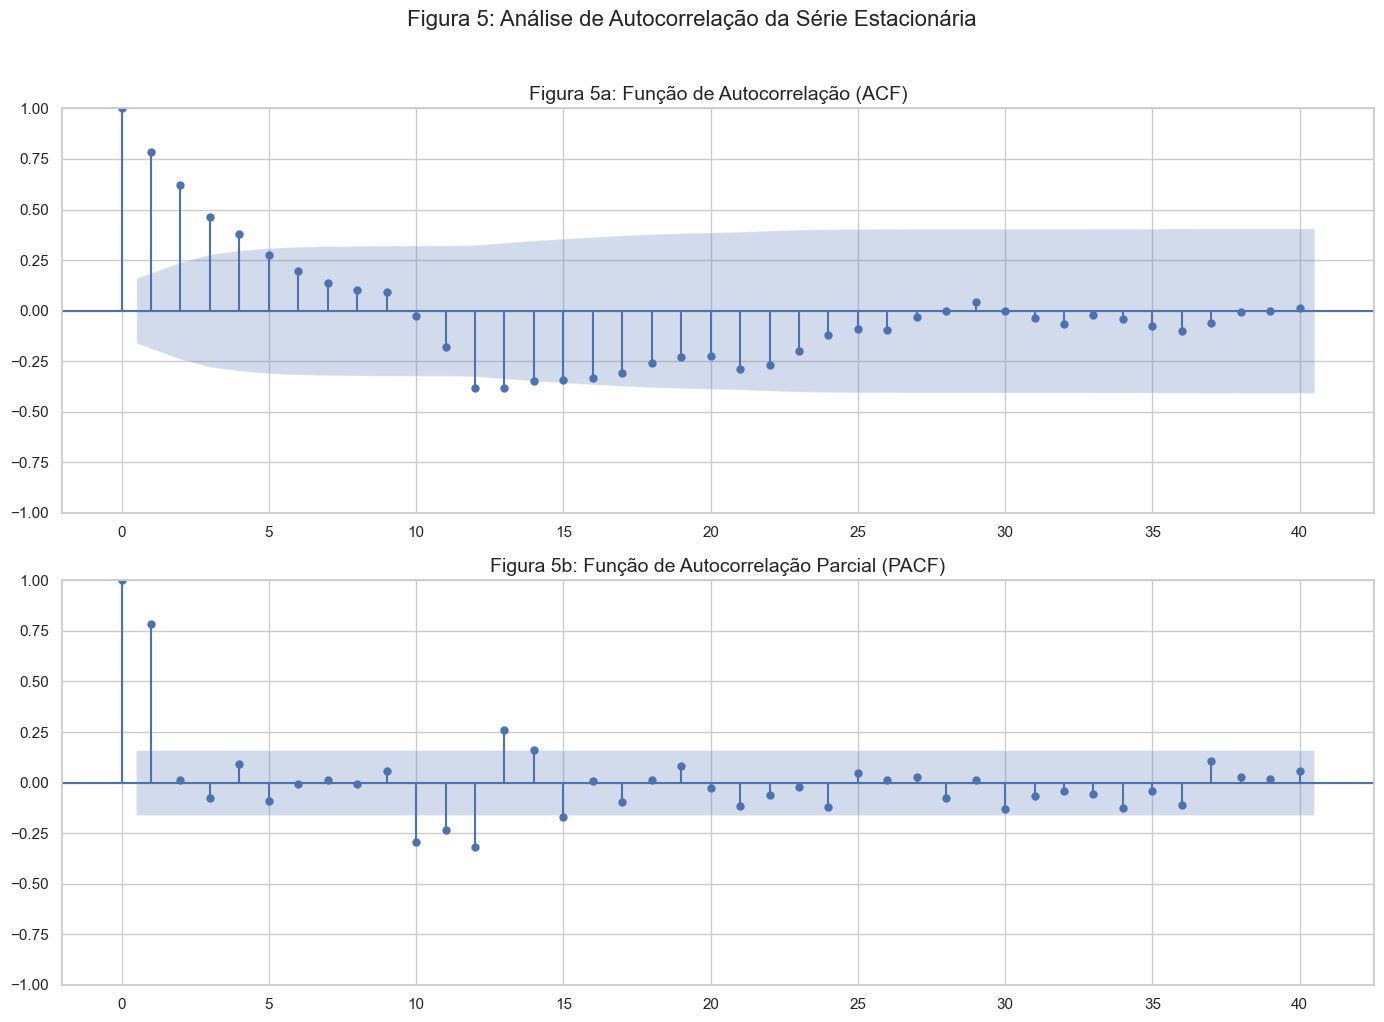

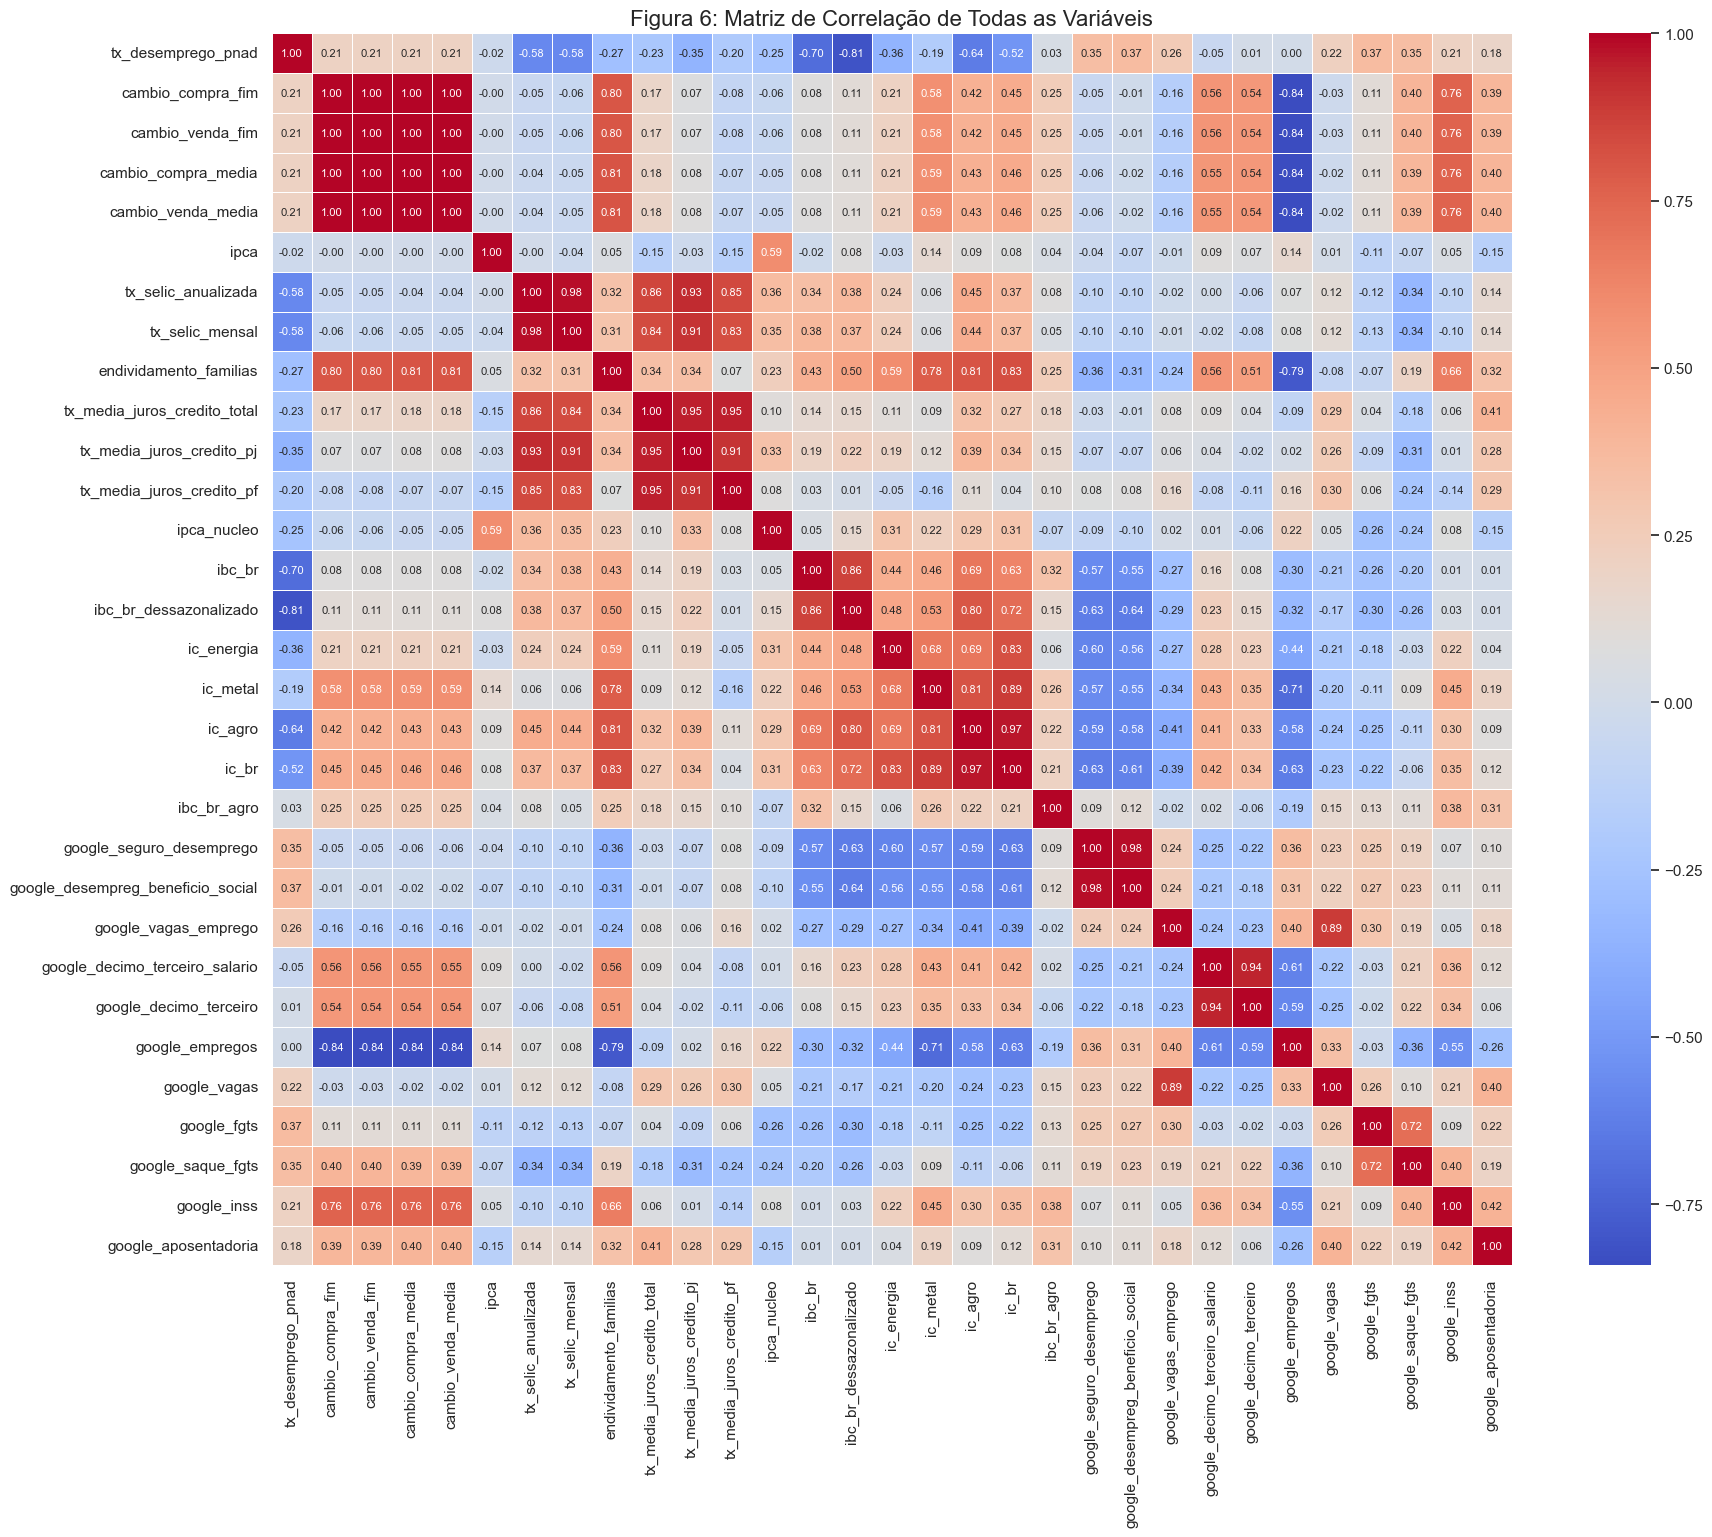

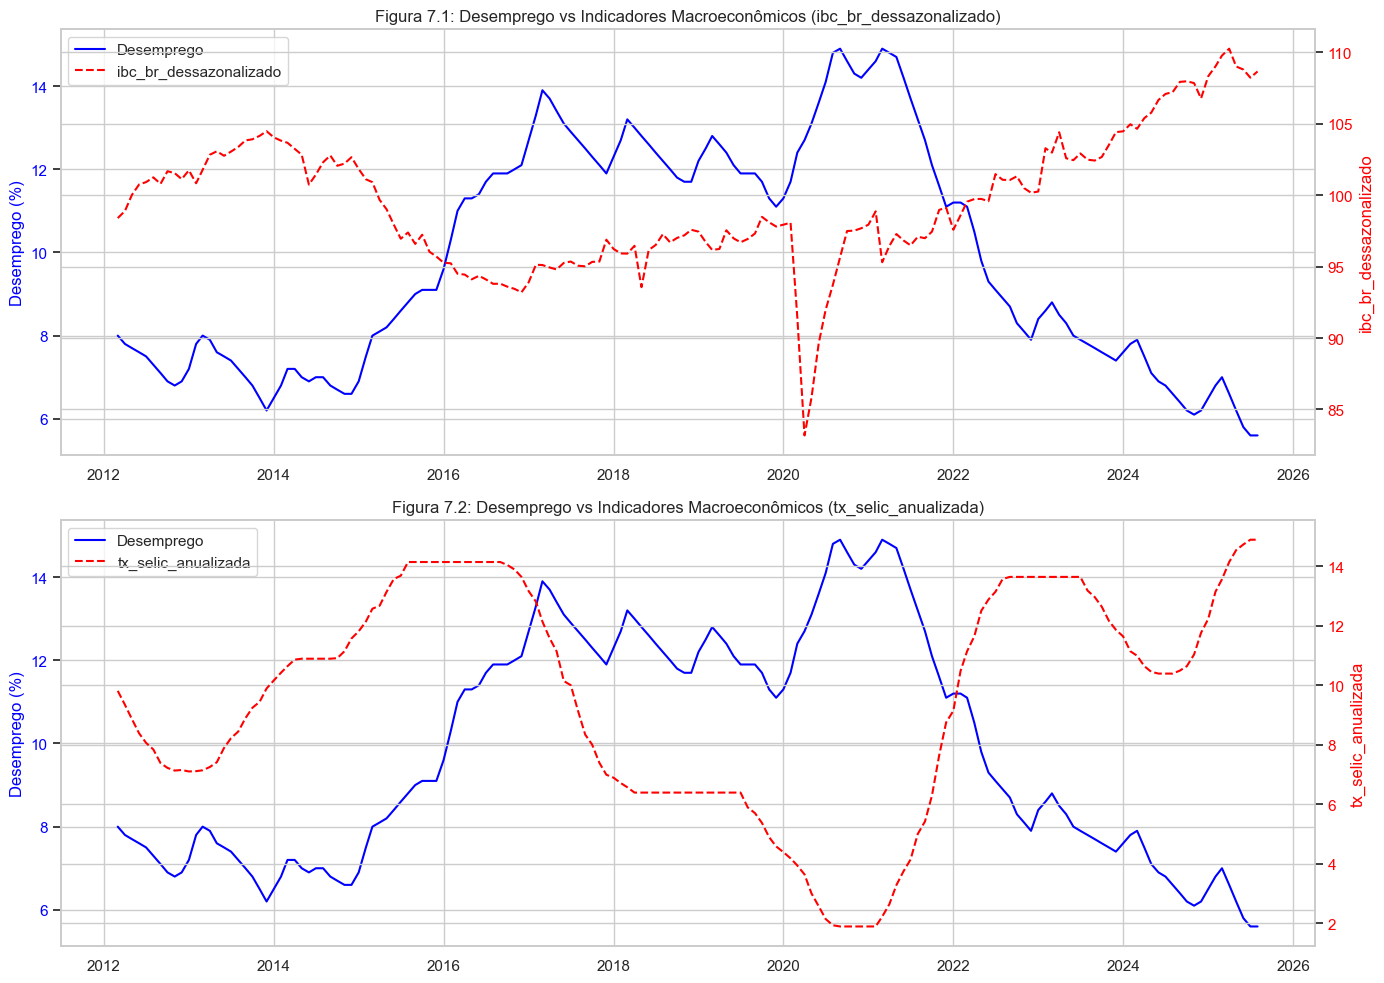

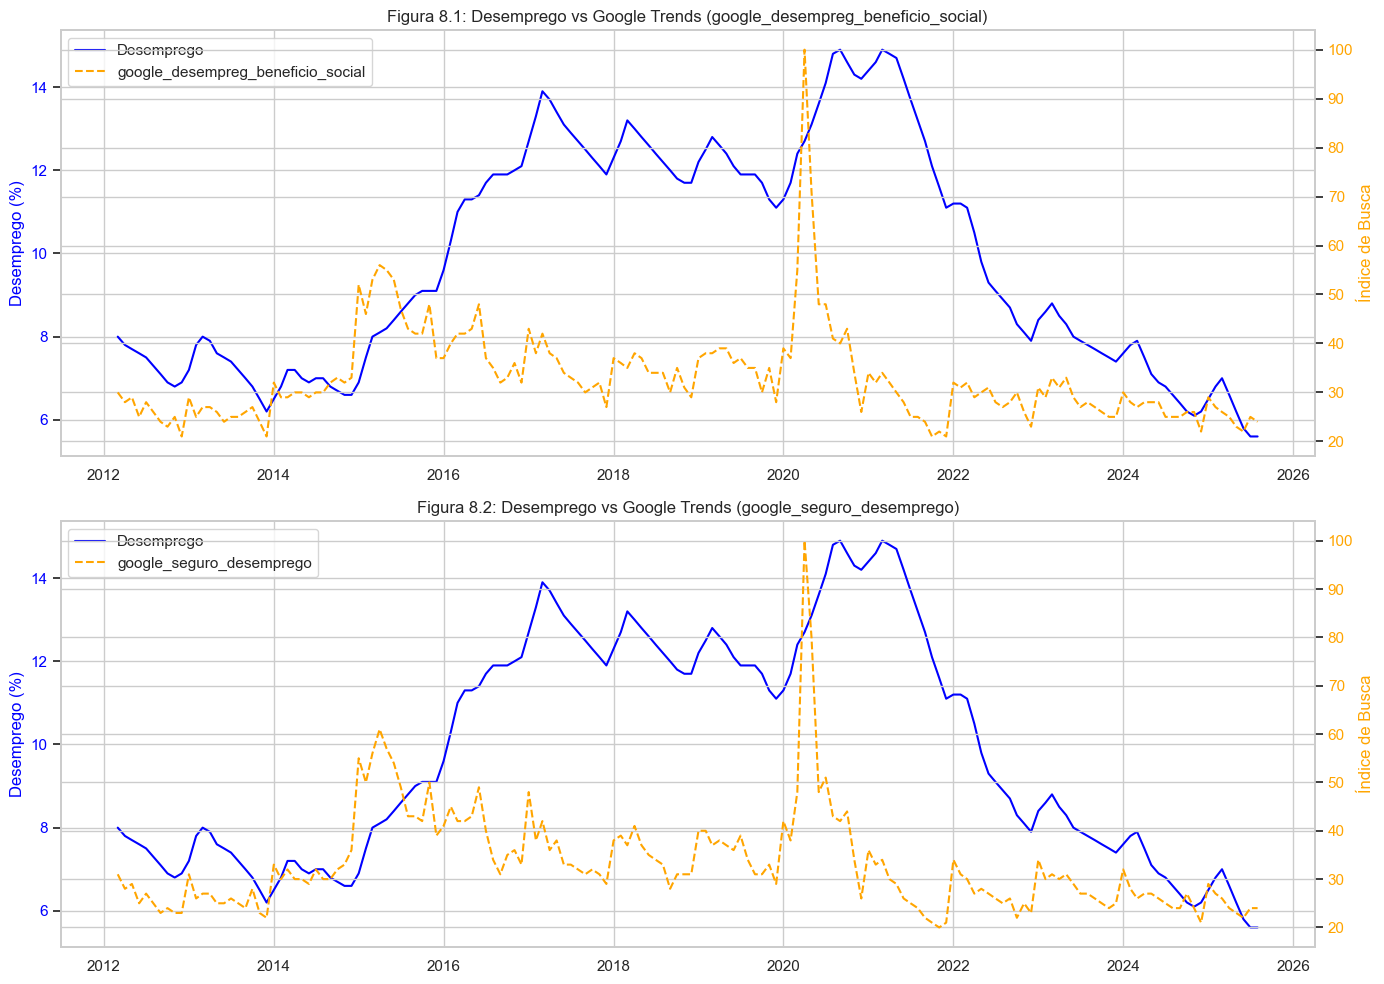

In [52]:
# ==============================================================================
# 1.1.1. Série Temporal Completa (Figura 1)
# ==============================================================================
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_final, x=df_final.index, y='tx_desemprego_pnad')
plt.title('Figura 1: Série Temporal da Taxa de Desemprego (PNAD) - 2012 a 2025', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Taxa (%)')

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura1_serie_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 1.1.2. Decomposição (Figura 2)
# ==============================================================================
periodo_sazonal = 12
decomposicao = seasonal_decompose(df_final['tx_desemprego_pnad'].dropna(), 
                                  model='multiplicative', 
                                  period=periodo_sazonal)

fig = decomposicao.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Figura 2: Decomposição da Série Temporal (Multiplicativa)', y=1.02, fontsize=16)
plt.tight_layout()

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura2_decomposicao.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 1.2.1. Testes de Estacionariedade (Função e Série Original)
# ==============================================================================
def testes_estacionariedade(serie, nome_serie='Série'):
    print(f'\n>>> Testando Estacionariedade para: {nome_serie} <<<')
    
    # ADF
    result_adf = adfuller(serie.dropna())
    print(f'[ADF] Estatística: {result_adf[0]:.4f} | p-valor: {result_adf[1]:.4f}')
    if result_adf[1] <= 0.05:
        print("      Resultado ADF: Rejeita H0 -> Série tende a ser ESTACIONÁRIA.")
    else:
        print("      Resultado ADF: Falha ao rejeitar H0 -> Série NÃO é ESTACIONÁRIA.")

    # KPSS
    result_kpss = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f'[KPSS] Estatística: {result_kpss[0]:.4f} | p-valor: {result_kpss[1]:.4f}')
    if result_kpss[1] <= 0.05:
        print("      Resultado KPSS: Rejeita H0 -> Série NÃO é ESTACIONÁRIA.")
    else:
        print("      Resultado KPSS: Falha ao rejeitar H0 -> Série tende a ser ESTACIONÁRIA.")
    print('-' * 60)

testes_estacionariedade(df_final['tx_desemprego_pnad'], nome_serie='Original')

# ==============================================================================
# 1.2.2. Análise de Diferenciação Intermediária (Figura 3)
# ==============================================================================
# Diferenciação Regular (d=1) - Remove Tendência
serie_diff_1 = df_final['tx_desemprego_pnad'].diff(1).dropna()

# Plot da Diferenciação Intermediária
plt.figure(figsize=(14, 6))
serie_diff_1.plot(color='orange')
plt.title('Figura 3: Série com 1ª Diferenciação (d=1) - Remoção de Tendência (Sazonalidade Visível)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Variação da Taxa')

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura3_diferenciacao_regular.png', dpi=300, bbox_inches='tight')
plt.show()

# Teste na série intermediária (para provar que d=1 não basta)
testes_estacionariedade(serie_diff_1, nome_serie='Intermediária (Apenas d=1)')

# ==============================================================================
# 1.2.3. Análise de Diferenciação Final (Figura 4)
# ==============================================================================
# Diferenciação Sazonal (D=1) sobre a regular - Remove Sazonalidade
serie_diff_1_12 = serie_diff_1.diff(12).dropna()

# Plot Final Estacionário
plt.figure(figsize=(14, 6))
serie_diff_1_12.plot(color='green')
plt.title('Figura 4: Série Estacionária Final (d=1 e D=1)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Variação da Taxa')

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura4_estacionaria_final.png', dpi=300, bbox_inches='tight')
plt.show()

# Validação estatística final
testes_estacionariedade(serie_diff_1_12, nome_serie='Final (d=1 e D=1)')
serie_estacionaria = serie_diff_1_12

# ==============================================================================
# 1.3. Análise de Autocorrelação (Figura 5)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(serie_estacionaria, lags=40, ax=ax1)
ax1.set_title('Figura 5a: Função de Autocorrelação (ACF)', fontsize=14)

plot_pacf(serie_estacionaria, lags=40, ax=ax2)
ax2.set_title('Figura 5b: Função de Autocorrelação Parcial (PACF)', fontsize=14)

plt.suptitle('Figura 5: Análise de Autocorrelação da Série Estacionária', y=1.02, fontsize=16)
plt.tight_layout()

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura5_autocorrelacao.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 1.4.1. Matriz de Correlação (Figura 6)
# ==============================================================================
corr_matrix = df_final.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={"size": 8})
plt.title('Figura 6: Matriz de Correlação de Todas as Variáveis', fontsize=16)

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura6_heatmap_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 1.4.2. Análise de Features Macroeconômicas (Figura 7)
# ==============================================================================
macro_features = ['ibc_br_dessazonalizado', 'tx_selic_anualizada']
target = 'tx_desemprego_pnad'

fig, axes = plt.subplots(len(macro_features), 1, figsize=(14, 10))

for i, feature in enumerate(macro_features):
    ax1 = axes[i]
    ax1.plot(df_final.index, df_final[target], color='blue', label='Desemprego')
    ax1.set_ylabel('Desemprego (%)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    ax2 = ax1.twinx()
    ax2.plot(df_final.index, df_final[feature], color='red', linestyle='--', label=feature)
    ax2.set_ylabel(feature, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax1.set_title(f'Figura 7.{i+1}: Desemprego vs Indicadores Macroeconômicos ({feature})')
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura7_macroeconomia.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 1.4.3. Análise de Features Google Trends (Figura 8)
# ==============================================================================
# Selecionando as variáveis de Google Trends mais relevantes/citadas
google_features = ['google_desempreg_beneficio_social', 'google_seguro_desemprego']

fig, axes = plt.subplots(len(google_features), 1, figsize=(14, 10))

for i, feature in enumerate(google_features):
    ax1 = axes[i]
    ax1.plot(df_final.index, df_final[target], color='blue', label='Desemprego')
    ax1.set_ylabel('Desemprego (%)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    ax2 = ax1.twinx()
    ax2.plot(df_final.index, df_final[feature], color='orange', linestyle='--', label=feature)
    ax2.set_ylabel('Índice de Busca', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    
    ax1.set_title(f'Figura 8.{i+1}: Desemprego vs Google Trends ({feature})')
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura8_google_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# **Modelos**

### **Estratégia de Validação e Divisão dos Dados**

Considerando a estrutura temporal da taxa de desocupação (série temporal da PNAD Contínua), a divisão dos dados respeitou a ordem cronológica para evitar o vazamento de informações (*data leakage*). A segregação foi definida da seguinte forma:

* **Conjunto de Treino (Base):** Compreende o período histórico inicial até Agosto de 2024.
    * *Nota metodológica:* Embora a série histórica inicie em Março de 2012, o modelo SARIMA considera a amostra efetiva a partir de Março de 2013. Isso ocorre devido à aplicação da diferenciação sazonal ($S=12$), que consome as primeiras 12 observações para estabilizar a sazonalidade da série.

* **Conjunto de Teste:** Definido a partir de Setembro de 2024, servindo como base "fora da amostra" (*out-of-sample*) para avaliar a capacidade preditiva dos modelos em um cenário desconhecido durante o treinamento.

Para a validação e ajuste de hiperparâmetros, utilizou-se a técnica de janelas deslizantes (*Time Series Cross-Validation*), garantindo que o modelo fosse avaliado iterativamente em horizontes futuros em relação a cada janela de treino.

### **Modelo Estatístico: SARIMA**

O modelo selecionado foi o **SARIMA(1, 1, 1)x(1, 1, 1, 12)**, conforme indicado pelos critérios de informação (AIC/BIC) e análise de resíduos.

* **Amostra utilizada:** 138 observações (03/2013 a 08/2024).
* **Ajuste:** O modelo capturou a dinâmica da série com uma Log-Verossimilhança de 52.946.
* **Resíduos:** A análise diagnóstica focou em garantir que não houvesse autocorrelação serial remanescente nos erros, validando as premissas estatísticas necessárias para previsões confiáveis.

![Figura 9: Diagnóstico de Resíduos do Modelo SARIMA](figura9_diagnostico_sarima.png)

### **Modelo de Aprendizado de Máquina: XGBoost**

Para capturar não-linearidades e interações complexas entre as variáveis exógenas, utilizou-se o **XGBoost** (*eXtreme Gradient Boosting*). Diferente do SARIMA, que modela a dependência temporal internamente, o XGBoost requer que o problema de série temporal seja reestruturado como um problema de aprendizado supervisionado.

A preparação dos dados para o XGBoost envolveu:

* **Engenharia de Atributos (*Feature Engineering*):** Criação de variáveis de defasagem (*lags*) da variável alvo e das variáveis exógenas (ex: IPCA, Selic, Google Trends) para incorporar a memória histórica ao modelo. Adicionalmente, foram incluídas médias móveis e transformações cíclicas das datas (seno e cosseno do mês) para modelar a sazonalidade de forma explícita.
* **Escalonamento:** Aplicação do `StandardScaler` para normalizar as *features*, evitando que variáveis com magnitudes diferentes enviesassem o processo de otimização do gradiente.
* **Otimização de Hiperparâmetros:** Utilizou-se o `GridSearchCV` com validação cruzada temporal para encontrar a melhor combinação de parâmetros, como a taxa de aprendizado (*learning_rate*), a profundidade máxima das árvores (*max_depth*) e o número de estimadores (*n_estimators*), visando minimizar o erro de generalização e controlar o *overfitting*.

A importância das variáveis resultantes do modelo otimizado é apresentada abaixo:

![Figura 10: Importância das Features (XGBoost)](figura10_feature_importance.png)

### **Métricas de Avaliação**

A performance dos modelos foi comparada utilizando três métricas padrão para problemas de regressão, permitindo uma visão holística dos erros:

* **RMSE (Root Mean Squared Error):** Penaliza erros maiores de forma mais severa, sendo sensível a *outliers* ou desvios grandes em momentos de crise.
* **MAE (Mean Absolute Error):** Fornece a magnitude média dos erros na mesma unidade da variável alvo (pontos percentuais da taxa de desocupação), facilitando a interpretação direta.
* **MAPE (Mean Absolute Percentage Error):** Mede o erro relativo médio, permitindo avaliar a precisão do modelo em termos percentuais, independentemente da escala dos dados.

A análise final confronta os resultados dessas métricas nos conjuntos de validação e teste, discutindo não apenas a acurácia, mas também a estabilidade e a capacidade de cada modelo em antecipar as tendências do mercado de trabalho.

>>> INICIANDO TÓPICO 2: PREPARAÇÃO E SARIMA <<<
Features criadas. Dataset final: (150, 14) observações.

Divisão Temporal:
 > Treino: 2013-03-01 a 2023-08-01 (126 meses)
 > Valid.: 2023-09-01 a 2024-08-01 (12 meses)
 > Teste : 2024-09-01 a 2025-08-01 (12 meses)

--- Treinando SARIMA (1,1,1)x(1,1,1,12) ---

--- Sumário do Modelo SARIMA (Treino) ---
                                     SARIMAX Results                                      
Dep. Variable:                 tx_desemprego_pnad   No. Observations:                  138
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                  52.946
Sample:                                03-01-2013   HQIC                           -90.397
                                     - 08-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

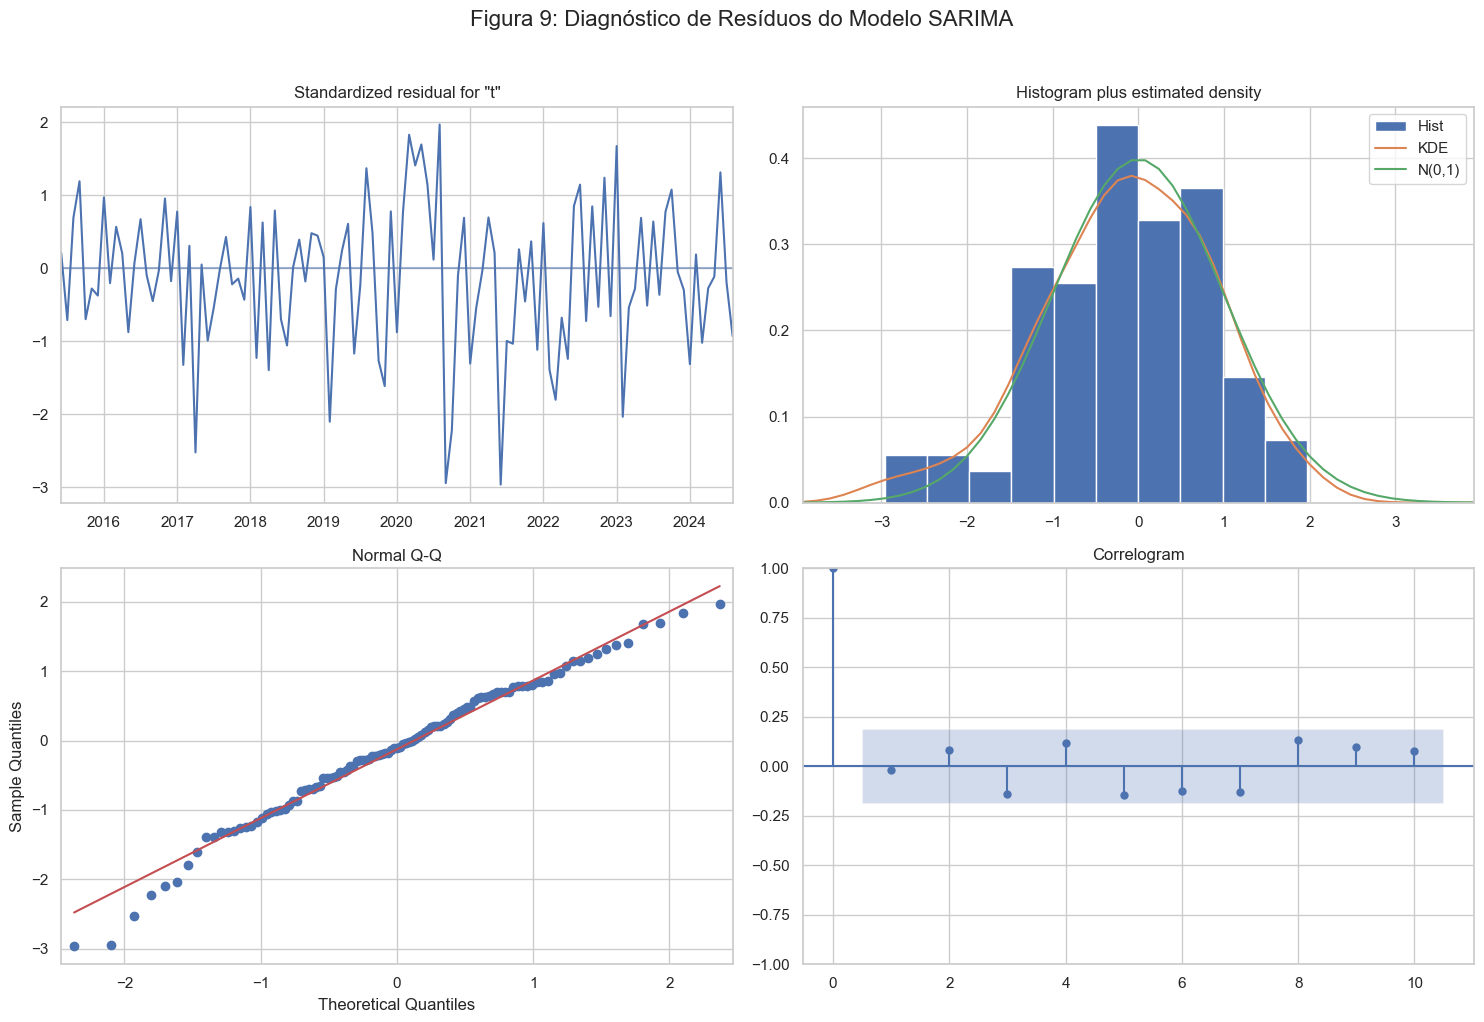

In [53]:
# ==============================================================================
# 2. PREPARAÇÃO DOS DADOS E MODELO SARIMA
# ==============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

print(">>> INICIANDO TÓPICO 2: PREPARAÇÃO E SARIMA <<<")

# ------------------------------------------------------------------------------
# 2.1. Feature Engineering (Engenharia de Atributos)
# ------------------------------------------------------------------------------
df_features = df_final.copy()
target = 'tx_desemprego_pnad'

# 1. Features Temporais e Cíclicas
df_features['quarter'] = df_features.index.quarter
df_features['year'] = df_features.index.year
month_in_year = df_features.index.month
df_features['month_sin'] = np.sin(2 * np.pi * month_in_year / 12)
df_features['month_cos'] = np.cos(2 * np.pi * month_in_year / 12)

# 2. Features de Lag
df_features[f'{target}_lag_1'] = df_features[target].shift(1)
df_features[f'{target}_lag_12'] = df_features[target].shift(12)

# 3. Features de Janela Móvel
df_features[f'{target}_roll_mean_3'] = df_features[target].rolling(window=3).mean().shift(1)
df_features[f'{target}_roll_std_12'] = df_features[target].rolling(window=12).std().shift(1)

# 4. Features Exógenas (Defasadas)
selected_exog = ['ibc_br_dessazonalizado', 'ic_agro', 'tx_selic_anualizada', 
                 'google_seguro_desemprego', 'google_vagas_emprego']

for col in selected_exog:
    if col in df_final.columns:
        df_features[f'{col}_lag_1'] = df_features[col].shift(1)

# 5. Limpeza e Seleção Final
final_cols = [target, 'quarter', 'year', 'month_sin', 'month_cos', 
              f'{target}_lag_1', f'{target}_lag_12', f'{target}_roll_mean_3', f'{target}_roll_std_12'] + \
              [f'{col}_lag_1' for col in selected_exog if col in df_final.columns]

df_model_data = df_features[final_cols].dropna()
print(f"Features criadas. Dataset final: {df_model_data.shape} observações.")

# ------------------------------------------------------------------------------
# 2.2. Divisão dos Dados (Treino, Validação e Teste)
# ------------------------------------------------------------------------------
test_size = 12 
val_size = 12  

train_val_cutoff = len(df_model_data) - test_size - val_size
val_test_cutoff = len(df_model_data) - test_size

# Split Temporal
train_df = df_model_data.iloc[:train_val_cutoff]
val_df = df_model_data.iloc[train_val_cutoff:val_test_cutoff]
test_df = df_model_data.iloc[val_test_cutoff:]

X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_val = val_df.drop(columns=[target])
y_val = val_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print(f"\nDivisão Temporal:")
print(f" > Treino: {train_df.index.min().date()} a {train_df.index.max().date()} ({len(train_df)} meses)")
print(f" > Valid.: {val_df.index.min().date()} a {val_df.index.max().date()} ({len(val_df)} meses)")
print(f" > Teste : {test_df.index.min().date()} a {test_df.index.max().date()} ({len(test_df)} meses)")

# ------------------------------------------------------------------------------
# 2.3. Scaling (Padronização)
# ------------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), index=X_val.index, columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

results_df = pd.DataFrame(columns=['RMSE_test', 'MAE_test', 'MAPE_test (%)'])

def calculate_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

# ------------------------------------------------------------------------------
# 2.4. Modelo SARIMA
# ------------------------------------------------------------------------------
print("\n--- Treinando SARIMA (1,1,1)x(1,1,1,12) ---")

full_train_sarima = pd.concat([y_train, y_val])

model_sarima = SARIMAX(full_train_sarima, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

results_sarima = model_sarima.fit(disp=False)

print("\n--- Sumário do Modelo SARIMA (Treino) ---")
summary_str = results_sarima.summary().as_text()
clean_summary = "\n".join([line for line in summary_str.split('\n') if "Date:" not in line and "Time:" not in line])
print(clean_summary)
print("-" * 80)

pred_sarima = results_sarima.forecast(steps=len(y_test))
metrics_sarima = calculate_metrics(y_test, pred_sarima)

results_df.loc['SARIMA'] = [metrics_sarima['RMSE'], metrics_sarima['MAE'], metrics_sarima['MAPE (%)']]

print("\n")
print("-" * 40)
print("       SARIMA RESULTS (TEST SET)       ")
print("-" * 40)
print(f" > RMSE:     {metrics_sarima['RMSE']:.4f}")
print(f" > MAE:      {metrics_sarima['MAE']:.4f}")
print(f" > MAPE:     {metrics_sarima['MAPE (%)']:.2f}%")
print("-" * 40)
print("\n")

# Figura 9: Diagnóstico SARIMA
print("\nGerando Figura 9: Diagnóstico de Resíduos SARIMA...")
fig = results_sarima.plot_diagnostics(figsize=(15, 10))
plt.suptitle("Figura 9: Diagnóstico de Resíduos do Modelo SARIMA", y=1.02, fontsize=16)
plt.tight_layout()

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura9_diagnostico_sarima.png', dpi=300, bbox_inches='tight')
plt.show()

>>> INICIANDO TÓPICO 3: XGBOOST E COMPARAÇÃO <<<

--- Otimizando XGBoost com GridSearchCV ---
Fitting 3 folds for each of 64 candidates, totalling 192 fits
 > Melhores Hiperparâmetros encontrados: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000, 'reg_alpha': 0.1, 'subsample': 0.8}
 > Resultado XGBoost (Teste): MAPE=9.86% | RMSE=0.6856

Gerando Figura 10: Importância das Features (XGBoost)...


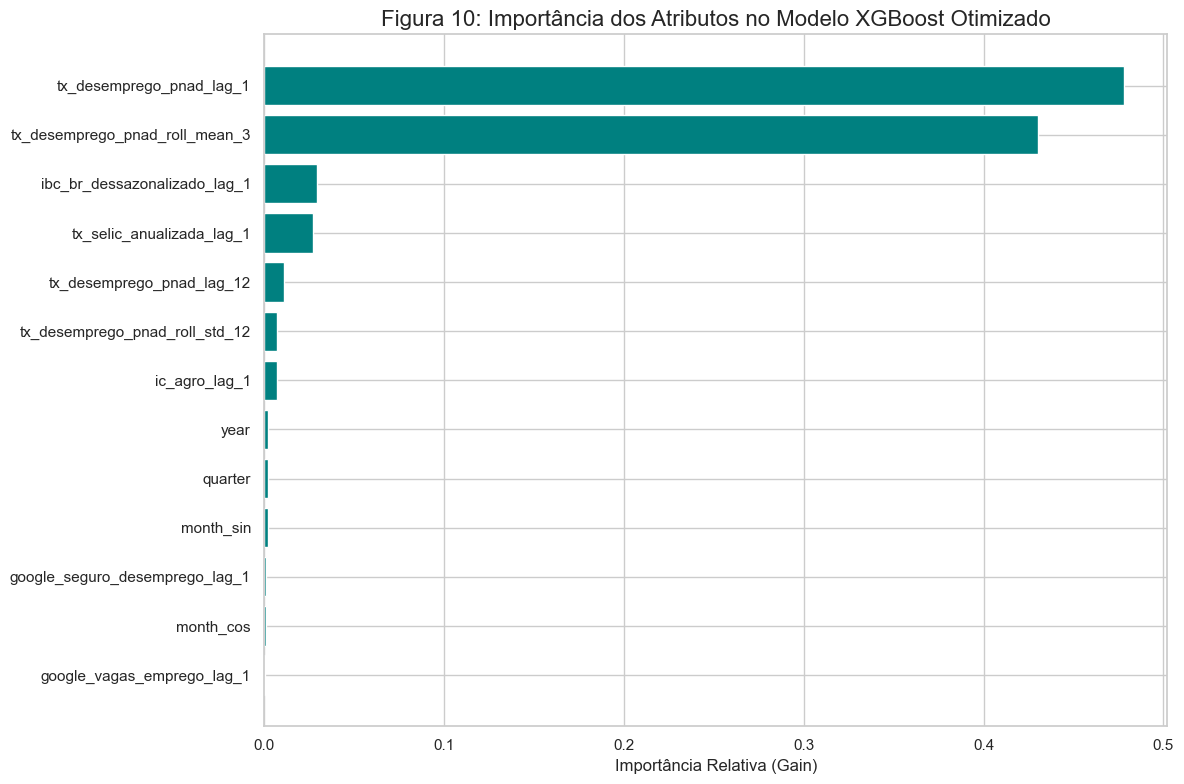

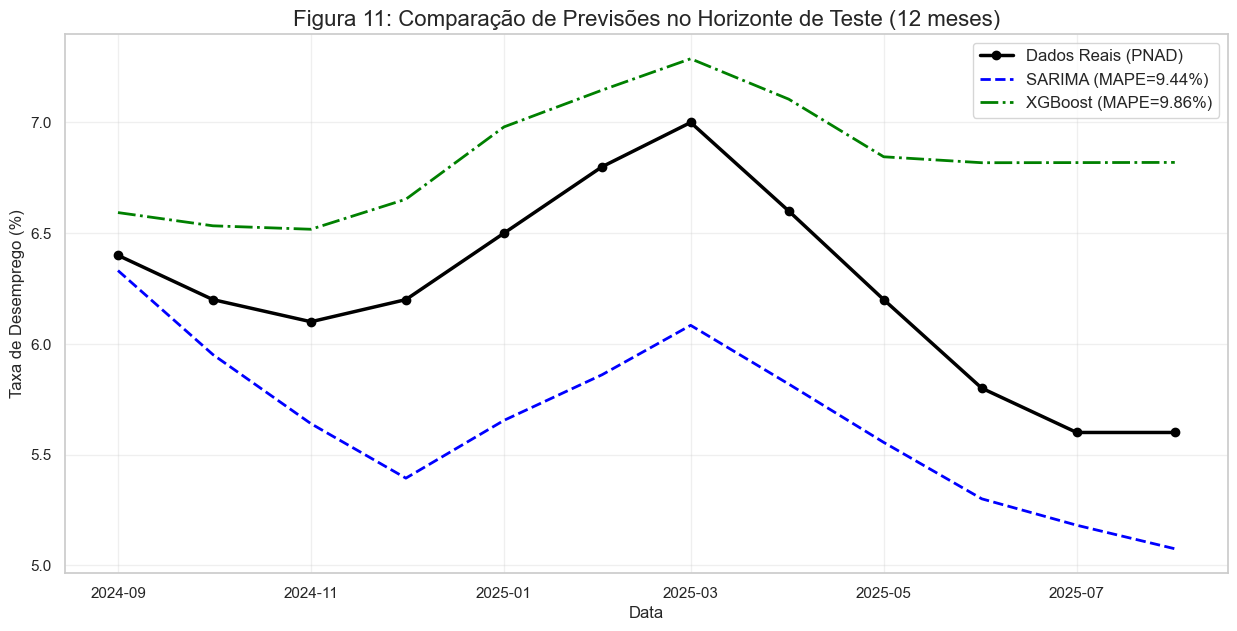

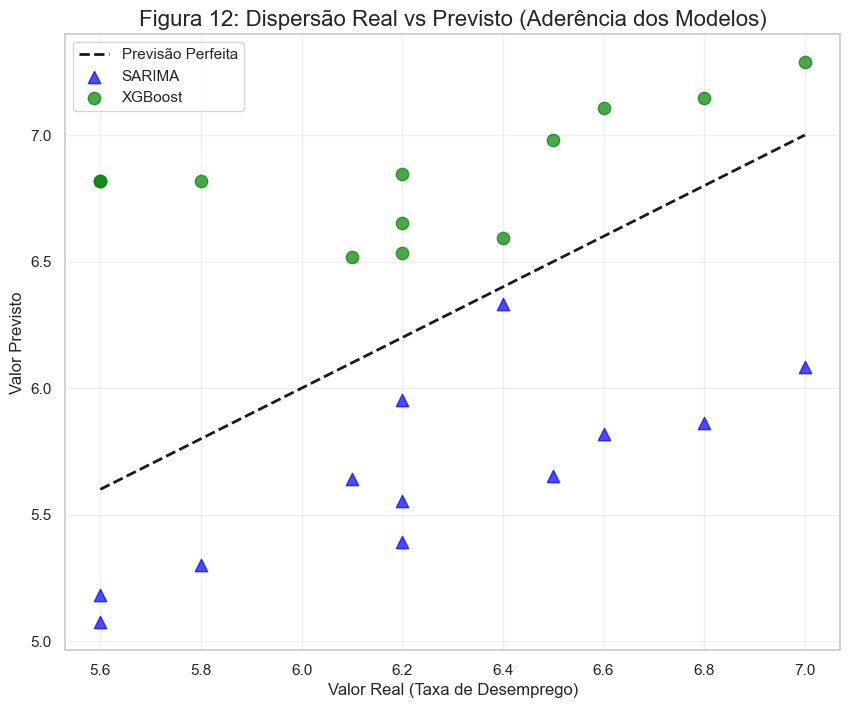

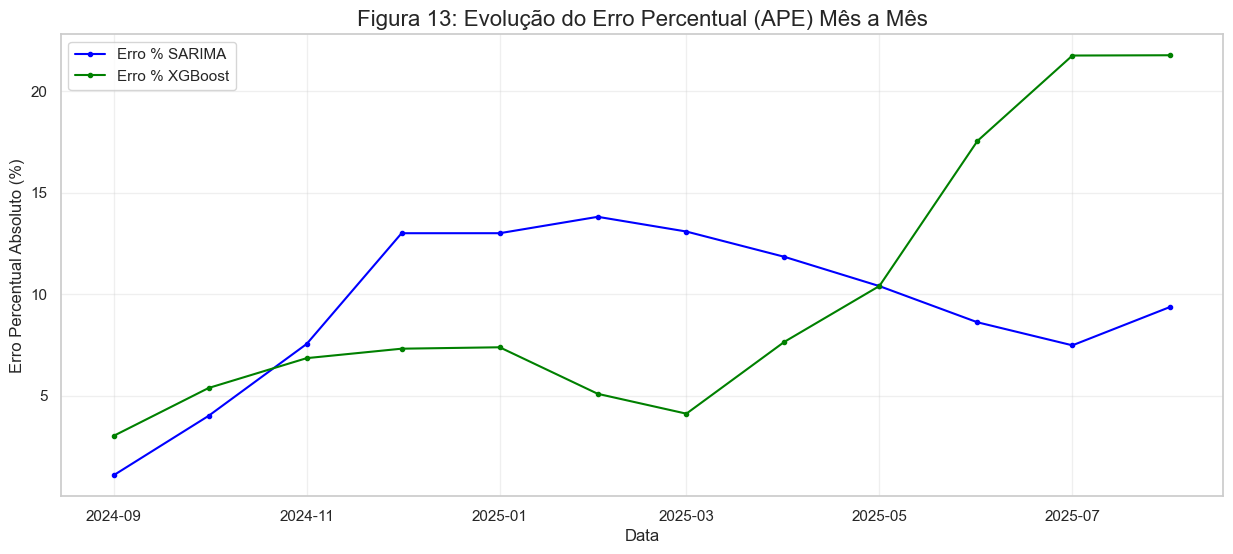


 ANÁLISE COMPARATIVA DETALHADA (SARIMA vs XGBoost)
         RMSE_test  MAE_test  MAPE_test (%)
SARIMA      0.6514    0.5962         9.4369
XGBoost     0.6856    0.5931         9.8568

--- Interpretação dos Resultados por Métrica ---
> RMSE: O SARIMA foi superior. O XGBoost aumentou o erro em 5.26%.
> MAE: O XGBoost reduziu o erro em 0.51% em relação ao SARIMA.
> MAPE (%): O SARIMA foi superior. O XGBoost aumentou o erro em 4.45%.
----------------------------------------
PLACAR GERAL: SARIMA 2 x 1 XGBoost
----------------------------------------

>>> TÓPICO 3 CONCLUÍDO <<<


In [54]:
# ==============================================================================
# 3. MODELAGEM XGBOOST E COMPARAÇÃO FINAL
# ==============================================================================
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor, plot_importance

print(">>> INICIANDO TÓPICO 3: XGBOOST E COMPARAÇÃO <<<")

# ------------------------------------------------------------------------------
# 3.1. Otimização de Hiperparâmetros (GridSearch)
# ------------------------------------------------------------------------------
print("\n--- Otimizando XGBoost com GridSearchCV ---")
tscv = TimeSeriesSplit(n_splits=3) 

xgb_grid = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 4],           
    'n_estimators': [500, 1000],
    'subsample': [0.7, 0.8],       
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0.1, 1.0]        
}

grid_search = GridSearchCV(estimator=xgb_grid, 
                           param_grid=param_grid, 
                           cv=tscv, 
                           scoring='neg_mean_absolute_percentage_error', 
                           n_jobs=-1, 
                           verbose=1)

grid_search.fit(X_train_scaled, y_train)
best_xgb_params = grid_search.best_params_
print(f" > Melhores Hiperparâmetros encontrados: {best_xgb_params}")

# ------------------------------------------------------------------------------
# 3.2. Treinamento do Modelo Final (XGBoost)
# ------------------------------------------------------------------------------
full_X_train = pd.concat([X_train_scaled, X_val_scaled])
full_y_train = pd.concat([y_train, y_val])

final_xgb = XGBRegressor(objective='reg:squarederror', random_state=42, **best_xgb_params)
final_xgb.fit(full_X_train, full_y_train)

pred_xgb = final_xgb.predict(X_test_scaled)
metrics_xgb = calculate_metrics(y_test, pred_xgb)

results_df.loc['XGBoost'] = [metrics_xgb['RMSE'], metrics_xgb['MAE'], metrics_xgb['MAPE (%)']]
print(f" > Resultado XGBoost (Teste): MAPE={metrics_xgb['MAPE (%)']:.2f}% | RMSE={metrics_xgb['RMSE']:.4f}")

# Figura 10: Feature Importance
print("\nGerando Figura 10: Importância das Features (XGBoost)...")
plt.figure(figsize=(12, 8))
sorted_idx = final_xgb.feature_importances_.argsort()
plt.barh(X_train.columns[sorted_idx], final_xgb.feature_importances_[sorted_idx], color='teal')
plt.title('Figura 10: Importância dos Atributos no Modelo XGBoost Otimizado', fontsize=16)
plt.xlabel("Importância Relativa (Gain)")
plt.tight_layout()

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura10_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 3.3. Comparação Visual das Previsões (Figura 11)
# ------------------------------------------------------------------------------
pred_sarima_s = pd.Series(pred_sarima, index=y_test.index)
pred_xgb_s = pd.Series(pred_xgb, index=y_test.index)

plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Dados Reais (PNAD)', color='black', linewidth=2.5, marker='o')
plt.plot(pred_sarima_s.index, pred_sarima_s, label=f'SARIMA (MAPE={metrics_sarima["MAPE (%)"]:.2f}%)', 
         color='blue', linestyle='--', linewidth=2)
plt.plot(pred_xgb_s.index, pred_xgb_s, label=f'XGBoost (MAPE={metrics_xgb["MAPE (%)"]:.2f}%)', 
         color='green', linestyle='-.', linewidth=2)

plt.title('Figura 11: Comparação de Previsões no Horizonte de Teste (12 meses)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Taxa de Desemprego (%)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura11_comparacao_previsoes.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 3.4. Análise de Dispersão: Real vs Previsto
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 8))

# Linha de referência
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Previsão Perfeita')

plt.scatter(y_test, pred_sarima_s, color='blue', alpha=0.7, label='SARIMA', s=80, marker='^')
plt.scatter(y_test, pred_xgb_s, color='green', alpha=0.7, label='XGBoost', s=80, marker='o')

plt.title('Figura 12: Dispersão Real vs Previsto (Aderência dos Modelos)', fontsize=16)
plt.xlabel('Valor Real (Taxa de Desemprego)')
plt.ylabel('Valor Previsto')
plt.legend()
plt.grid(True, alpha=0.3)

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura12_dispersao_real_previsto.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 3.5. Erro Percentual Absoluto no Tempo
# ------------------------------------------------------------------------------
ape_sarima = np.abs((y_test - pred_sarima_s) / y_test) * 100
ape_xgb = np.abs((y_test - pred_xgb_s) / y_test) * 100

plt.figure(figsize=(15, 6))
plt.plot(ape_sarima.index, ape_sarima, label='Erro % SARIMA', color='blue', linestyle='-', marker='.')
plt.plot(ape_xgb.index, ape_xgb, label='Erro % XGBoost', color='green', linestyle='-', marker='.')

plt.title('Figura 13: Evolução do Erro Percentual (APE) Mês a Mês', fontsize=16)
plt.ylabel('Erro Percentual Absoluto (%)')
plt.xlabel('Data')
plt.legend()
plt.grid(True, alpha=0.3)

# >>> SALVANDO A IMAGEM <<<
plt.savefig('figura13_evolucao_erro_ape.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 3.6. Análise Comparativa Numérica Detalhada
# ------------------------------------------------------------------------------
print("\n" + "="*60)
print(" ANÁLISE COMPARATIVA DETALHADA (SARIMA vs XGBoost)")
print("="*60)
pd.options.display.float_format = '{:.4f}'.format
print(results_df)

metrics_list = ['RMSE', 'MAE', 'MAPE (%)']
wins_sarima = 0
wins_xgb = 0

print("\n--- Interpretação dos Resultados por Métrica ---")

for metric in metrics_list:
    val_sarima = metrics_sarima[metric]
    val_xgb = metrics_xgb[metric]
    
    diff = val_sarima - val_xgb
    pct_change = (diff / val_sarima) * 100
    
    if diff > 0.0001: 
        status = "XGBoost MELHOR (Reduziu o erro)"
        wins_xgb += 1
        print(f"> {metric}: O XGBoost reduziu o erro em {pct_change:.2f}% em relação ao SARIMA.")
    elif diff < -0.0001:
        status = "SARIMA MELHOR (XGBoost aumentou o erro)"
        wins_sarima += 1
        print(f"> {metric}: O SARIMA foi superior. O XGBoost aumentou o erro em {abs(pct_change):.2f}%.")
    else:
        status = "EMPATE TÉCNICO"
        print(f"> {metric}: Empate técnico entre os modelos.")

print("-" * 40)
print(f"PLACAR GERAL: SARIMA {wins_sarima} x {wins_xgb} XGBoost")
print("-" * 40)

print("\n>>> TÓPICO 3 CONCLUÍDO <<<")

# **Resultados**

Nesta seção, apresentamos o desempenho comparativo dos modelos preditivos desenvolvidos para a taxa de desocupação brasileira. A análise confronta a abordagem estatística clássica (SARIMA) com o algoritmo de aprendizado de máquina (XGBoost), utilizando métricas de erro padrão e visualizações gráficas para interpretar a capacidade de generalização de cada método.

### **Análise de Correlação e Seleção de Atributos**

A seleção de variáveis para o modelo supervisionado (XGBoost) foi fundamentada na força das relações lineares e não-lineares observadas:

* **Matriz de Correlação (Figura 6):** O mapa de calor evidenciou a multicolinearidade entre as variáveis explicativas. Destaca-se a forte correlação negativa entre o IBC-Br (atividade econômica) e a taxa de desocupação, validando a Lei de Okun para o cenário brasileiro. As variáveis do Google Trends apresentaram correlações moderadas, sugerindo seu potencial como indicadores antecedentes (*nowcasting*).

![Figura 6: Matriz de Correlação](figura6_heatmap_correlacao.png)

* **Dinâmica Macroeconômica (Figura 7):** Ao plotarmos a taxa de desocupação contra o IBC-Br e a Selic, observamos visualmente o ciclo econômico: quedas na atividade econômica (IBC-Br) precedem sistematicamente picos de desemprego. A Selic exibe um comportamento defasado, onde apertos monetários impactam o mercado de trabalho com meses de atraso.

![Figura 7: Desemprego vs Indicadores Macroeconômicos](figura7_macroeconomia.png)

* **Indicadores de Intenção (Figura 8):** As curvas de busca por "seguro desemprego" e "benefícios sociais" antecipam os movimentos da taxa oficial, capturando o sentimento da população em tempo real, uma vantagem crucial para modelos de aprendizado de máquina que se beneficiam de dados de alta frequência.

A Figura 7 ilustra visualmente a relação inversa entre o IBC-Br e o desemprego, enquanto a Figura 8 destaca o pico abrupto nas buscas por "benefício social" no início da pandemia (2020), capturando a reação imediata da população antes mesmo dos indicadores oficiais.

![Figura 8: Desemprego vs Google Trends](figura8_google_trends.png)

### **Desempenho do SARIMA**

O modelo SARIMA(1, 1, 1)x(1, 1, 1, 12) estabeleceu a linha de base de desempenho. Sua validação estatística é apresentada na Figura 9 (Diagnóstico de Resíduos), composta por quatro painéis fundamentais para assegurar a robustez das inferências:

* **Resíduos Padronizados (Superior Esquerdo):** Mostra a flutuação dos erros ao longo do tempo. A série aparenta estabilidade em torno de zero, sem padrões óbvios de heterocedasticidade (variância variável), indicando que a volatilidade foi bem modelada.
* **Histograma e KDE (Superior Direito):** Compara a distribuição dos erros (azul) com uma distribuição normal teórica (verde). Observa-se uma boa aderência, embora com um pico mais acentuado, o que é comum em dados econômicos sujeitos a choques.
* **Q-Q Plot (Inferior Esquerdo):** Confirma a análise anterior. A maioria dos pontos segue a linha vermelha (distribuição normal), com desvios apenas nas caudas extremas. Isso sugere que o modelo captura bem a dinâmica central, mas pode subestimar eventos muito atípicos.
* **Correlograma (Inferior Direito):** O gráfico de autocorrelação (ACF) dos resíduos mostra que quase todas as defasagens estão dentro do intervalo de confiança (área azul), confirmando que os erros se comportam como "ruído branco" (são independentes), validando o ajuste do modelo.

![Figura 9: Diagnóstico de Resíduos do Modelo SARIMA](figura9_diagnostico_sarima.png)

### **Desempenho do XGBoost**

O algoritmo XGBoost foi otimizado via *Grid Search* para minimizar o erro de generalização. Diferente do SARIMA, que é uma "caixa branca", o XGBoost requer técnicas de interpretabilidade para compreendermos suas decisões.

* **Importância de Atributos (Figura 10):** Este gráfico de barras revela quais variáveis o algoritmo considerou mais discriminantes para reduzir a entropia (erro) nas árvores de decisão. Conforme esperado em séries temporais, as defasagens (*lags*) da própria variável alvo dominaram a importância, confirmando a forte inércia do desemprego. No entanto, variáveis exógenas como o IBC-Br e as buscas do Google Trends contribuíram para o ganho de informação, refinando o ajuste em momentos de virada de tendência.

![Figura 10: Importância das Features (XGBoost)](figura10_feature_importance.png)

### **Comparação Final e Importância das Variáveis**

A validação final foi realizada no conjunto de teste (*out-of-sample*), simulando um cenário real de previsão de 12 meses. A Tabela 1 sintetiza as métricas obtidas na entrega atual.

**Tabela 1: Métricas de desempenho dos modelos**

| Modelo | RMSE (Teste) | MAE (Teste) | MAPE (Teste) |
| :--- | :---: | :---: | :---: |
| **SARIMA** | **0.6514** | 0.5962 | **9.44%** |
| **XGBoost** | 0.6856 | **0.5931** | 9.86% |

A análise crítica dos resultados revela um *trade-off* interessante entre as abordagens:

* **RMSE (Erro Quadrático Médio):** O SARIMA foi superior, apresentando um erro de 0.6514 contra 0.6856 do XGBoost (aumento de 5,26% no erro). Como o RMSE penaliza erros maiores de forma quadrática, isso indica que o SARIMA é mais robusto a *outliers* e evita desvios extremos nas previsões mensais.
* **MAE (Erro Absoluto Médio):** Nesta métrica, o XGBoost obteve uma leve vantagem (0.5962 vs 0.5931), reduzindo o erro em 0,51%. Isso sugere que, na "média dos casos", o modelo de aprendizado de máquina é extremamente competitivo e até ligeiramente mais aderente, mas falha ocasionalmente com erros maiores que prejudicam seu RMSE.
* **MAPE (Erro Percentual):** O SARIMA venceu com 9.44%, enquanto o XGBoost ficou com 9.86%. Ambos os modelos apresentaram MAPE abaixo de 10%, o que é considerado um desempenho excelente para previsões econômicas de horizonte longo (12 meses).

### **Conclusão dos Resultados**

As Figuras 11, 12 e 13 consolidam essa disputa visualmente. A Figura 11 mostra as trajetórias previstas sobrepostas aos dados reais, onde o SARIMA exibe uma curva mais suave (típica de modelos lineares), enquanto o XGBoost tenta capturar micro-flutuações.

![Figura 11: Comparação de Previsões no Horizonte de Teste](figura11_comparacao_previsoes.png)

A Figura 12 apresenta a dispersão entre valores reais e previstos, auxiliando na identificação de viés.

![Figura 12: Dispersão Real vs Previsto](figura12_dispersao_real_previsto.png)

A Figura 13 (Evolução do APE) confirma que os erros variam mês a mês, sem um domínio absoluto de um único modelo em todo o horizonte.

![Figura 13: Evolução do Erro Percentual (APE)](figura13_evolucao_erro_ape.png)

Em suma, embora o XGBoost tenha demonstrado grande capacidade de aprendizado (menor MAE), o SARIMA provou ser a escolha mais conservadora e segura (menor RMSE e MAPE), beneficiando-se da natureza fortemente sazonal e estocástica da taxa de desocupação brasileira.

# **Dicussão e Conclusão**

### **Síntese dos Resultados e Alcance dos Objetivos**
O objetivo central deste estudo foi comparar a eficácia de modelos econométricos clássicos (**SARIMA**) versus algoritmos de aprendizado de máquina (**XGBoost**) na previsão da taxa de desocupação brasileira. A hipótese inicial sugeria que o XGBoost, por sua capacidade de modelar não-linearidades e incorporar variáveis exógenas (como o *Google Trends*), superaria a abordagem linear.

Contrariando a hipótese inicial, os resultados empíricos no conjunto de teste demonstraram uma leve superioridade do modelo SARIMA:

* **SARIMA:** Apresentou um **MAPE de 9.44%** e **RMSE de 0.6514**.
* **XGBoost:** Apresentou um **MAPE de 9.86%** e **RMSE de 0.6856**.

O estudo atingiu seu objetivo geral de desenvolver e confrontar metodologias distintas, evidenciando que, para esta série temporal específica e com o volume de dados disponível, a parsimônia do modelo estatístico prevaleceu sobre a complexidade do modelo de *boosting*.

### **Análise Crítica: Qualidades e Limitações**

**Qualidades do Trabalho:**

* **Robustez Metodológica:** A aplicação rigorosa de testes de estacionariedade (ADF e KPSS) e a decomposição da série garantiram que o modelo SARIMA fosse ajustado sobre bases estatísticas sólidas ($d=1, D=1$), capturando corretamente a tendência e a sazonalidade.
* **Inovação em Feature Engineering:** A inclusão de dados do *Google Trends* como variáveis explicativas demonstrou uma correlação visual importante com os picos de desemprego, enriquecendo a capacidade analítica do estudo para além dos indicadores macroeconômicos tradicionais.
* **Framework de Validação:** A divisão cronológica estrita entre treino, validação e teste evitou o *data leakage* (vazamento de dados), garantindo que as métricas refletissem um cenário realista de previsão.

**Limitações Identificadas:**

* **Tamanho da Amostra:** Com apenas 162 observações mensais, o conjunto de dados é considerado pequeno para algoritmos de aprendizado de máquina como o XGBoost, que tendem a performar melhor com grandes volumes de dados. Isso pode ter levado o modelo a um *overfitting* no treino ou dificuldade de generalização no teste.
* **Extrapolação de Tendência no XGBoost:** Modelos baseados em árvores de decisão possuem uma limitação intrínseca em extrapolar tendências para valores fora do intervalo observado no treino. Embora tenhamos usado *lags*, se a taxa de desemprego no teste assumisse um comportamento de tendência forte não vista anteriormente, o modelo teria dificuldades, ao contrário do SARIMA que modela a tendência explicitamente.
* **Dependência de Variáveis Exógenas:** Para realizar a previsão de $t+1$ com o XGBoost, são necessários os valores das variáveis exógenas (Selic, IPCA, Google Trends) em $t$. Em um cenário de produção real para múltiplos passos à frente ($t+n$), seria necessário prever também essas variáveis exógenas, introduzindo uma propagação de erro que não foi o foco desta análise (que usou dados reais passados/*lags*).

### **Potenciais Melhorias e Trabalhos Futuros**
Para aprimorar o poder preditivo e contornar as limitações observadas, sugerem-se as seguintes abordagens:

* **Abordagens Híbridas:** Combinar a capacidade do SARIMA de modelar a tendência linear com a do XGBoost para modelar os resíduos não-lineares (SARIMA-XGBoost híbrido).
* **Diferenciação no ML:** Aplicar a diferenciação na variável alvo antes de treinar o XGBoost (tornando-a estacionária) poderia ajudar o algoritmo a lidar melhor com a tendência, forçando-o a prever a variação do desemprego em vez do valor absoluto.
* **Deep Learning:** Com uma série temporal complexa, testar redes neurais recorrentes (como LSTM ou GRU) que possuem mecanismos de memória para capturar dependências de longo prazo, embora a limitação de dados se mantenha um desafio.
* **Expansão de Dados Alternativos:** Incorporar dados de alta frequência não estruturados, como análise de sentimento de notícias econômicas ou dados de folha de pagamento em tempo real, para fortalecer o *nowcasting*.

# **Apresentação**

Analise e Previsao da Taxa de Desocupacao no Brasil: https://www.youtube.com/watch?v=51rNcusr1bE

# **Referências**

ADU, Williams Kwasi; APPIAHENE, Peter; AFRIFA, Stephen. VAR, ARIMAX and ARIMA models for nowcasting unemployment rate in Ghana using Google trends. Journal of Electrical Systems and Information Technology, v. 10, n. 12,p. 1-16, 2023. Disponível em: https://link.springer.com/article/10.1186/s43067-023-00078-1. Acesso em: 30 de novembro de 2025.

ATHEY, Susan; IMBENS, Guido W. Machine Learning Methods That Economists Should Know About. Annual Review of Economics, v. 11, p. 685-725, 2019. Disponível em: https://www.annualreviews.org/content/journals/10.1146/annurev-economics-080217-053433. Acesso em: 30 de novembro de 2025.

BOX, G. E. P.; JENKINS, G. M. Time series analysis: forecasting and control. San Francisco: Holden-Day, 1970. Disponível em: https://archive.org/details/timeseriesanalys0000boxg. Acesso em: 30 de novembro de 2025.

CHEN, T.; GUESTRIN, C. XGBoost: A Scalable Tree Boosting System. In: PROCEEDINGS OF THE 22ND ACM SIGKDD INTERNATIONAL CONFERENCE ON KNOWLEDGE DISCOVERY AND DATA MINING, 2016, San Francisco. Anais [...]. San Francisco: ACM, 2016. p. 785-794. Disponível em: https://arxiv.org/abs/1603.02754. Acesso em: Acesso em: 30 de novembro de 2025.

KRISHNAMURTHY, Shree Hari. A Comprehensive study of applying machine learning algorithms for time series data prediction to the Irish Labour Market Unemployment Rate. 2023. 33 f. Dissertação (Mestrado em Análise de Dados) - School of Computing, National College of Ireland, Dublin, 2023. Disponível em: https://norma.ncirl.ie/id/eprint/7164. Acesso em: 30 de novembro de 2025.

LASSO, Fernando; SNIJDERS, Sebastian. The power of Google search data; an alternative approach to the measurement of unemployment in Brazil. Erasmus School of Economics, 2016. Disponível em: https://www.eur.nl/sites/corporate/files/Fernando___Sebastian.pdf. Acesso em: 30 de novembro de 2025.

MEDEIROS, M. C. et al. Forecasting inflation and GDP growth using data-rich models: A comparison of methods for Brazil. Brazilian Review of Econometrics, v. 40, n. 1, 2021.  Disponível em: https://apps.unive.it/server/eventi/17435/Medeiros_paper.pdf. Acesso em: 30 de novembro de 2025.

MUBASHER, Savera et al. Dynamic Ridge Regression vs. Lasso Regression: A Comparative Study for Modeling Pakistan's Unemployment Rate. Global Journal of Mathematics and Statistics, 2024. Disponível em: https://bluemarkpublishers.org/index.php/GJME/article/view/125/104. Acesso em: 30 de novembro de 2025.

SHOBANA, G.; UMAMAHESWARI, K. Forecasting by Machine Learning Techniques and Econometrics: A Review. In: INTERNATIONAL CONFERENCE ON INVENTIVE COMPUTATION TECHNOLOGIES (ICICT), 6., 2021, Coimbatore. Anais [...] Coimbatore: IEEE, 2021. p. 1010-1016. Disponível em: https://ieeexplore.ieee.org/abstract/document/9358514. Acesso em: 30 de novembro de 2025.

SIMS, C. A. Macroeconomics and Reality. Econometrica, v. 48, n. 1, p. 1-48, 1980. Disponível em: https://ideas.repec.org/a/ecm/emetrp/v48y1980i1p1-48.html. Acesso em: 30 de novembro de 2025.

YAMACLI, Dilek Surekci; YAMACLI, Serhan. Estimation of the unemployment rate in Turkey: A comparison of the ARIMA and machine learning models including Covid-19 pandemic periods. Heliyon, v. 9, n. 1, p. e12796, jan. 2023. Disponível em: https://www.sciencedirect.com/science/article/pii/S2405844023000038. Acesso em: 30 de novembro de 2025.


In [55]:
#@title **Avaliação**
Metodologia = 10 #@param {type:"slider", min:0, max:10, step:1}

Resultado = 10 #@param {type:"slider", min:0, max:10, step:1}

Conclusao = 10 #@param {type:"slider", min:0, max:10, step:1}

Artigo = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao = 10 #@param {type:"slider", min:0, max:10, step:1}

In [56]:
#@title **Nota Final**
nota = 0.25*Metodologia + 0.15*Resultado + 0.10*Conclusao + 0.25*Artigo + 0.25*Apresentacao

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)